# UTR HPO Decision and PARADE Checkpoint Evaluation, May 2026

This notebook consolidates the UTR pretrained-model decision work with the released Goodarzi/PARADE checkpoint evaluation.

What this notebook does:

- summarizes Hani/Goodarzi 3'UTR and 5'UTR HPO sweeps from `src/learn/run_registry/runs.csv`;
- keeps official BODA selection validation-first and treats test/Lib2/literature comparisons as critique;
- evaluates released PARADE 3'UTR and 5'UTR checkpoints from `external_models/parade`;
- confirms the released checkpoints reproduce the PARADE authors' public notebook numbers, then uses a single PARADE series in downstream plots;
- compares PARADE with the current canonical BODA UTR models in `src/learn/run_registry/best_runs.csv`;
- scores exact-length in-house `FivePrime` candidates and reports why current 3'UTR checkpoints are not directly valid for mostly 100-nt `ThreePrime` candidates;
- writes reusable CSVs and plots under `presentation_plots/parade_released_checkpoint_eval_may2026/`.

Run this notebook from `boda_env` or another environment with `torch`, `pytorch_lightning`, and BODA importable.


In [14]:
from pathlib import Path
import ast
import itertools
import json
import math
import os
import re
import sys
import tarfile
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 180)
pd.set_option('display.max_colwidth', 160)

try:
    import torch
    import pytorch_lightning as pl
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook needs the BODA/PARADE torch stack. Start Jupyter from boda_env, "
        "or run: conda run -n boda_env jupyter lab"
    ) from exc

WORK_ROOT = Path('/home/minhang/synBio_AL')
REPO_ROOT = WORK_ROOT / 'boda2_EU'
LEARN_ROOT = REPO_ROOT / 'src' / 'learn'
RUNS_CSV = LEARN_ROOT / 'run_registry' / 'runs.csv'
WANDB_ROOT = LEARN_ROOT / 'wandb'
PARADE_ROOT = WORK_ROOT / 'external_models' / 'parade' / 'parade'
PARADE_MODEL_DIR = PARADE_ROOT / 'predictor' / 'model'
PARADE_CKPTS = {
    '3UTR': PARADE_ROOT / 'predictor' / 'regression_multiple' / 'saved_models' / 'model-utr3-deltas-epoch=9-step=1330.ckpt',
    '5UTR': PARADE_ROOT / 'predictor' / 'regression_multiple' / 'saved_models' / 'model-utr5-deltas-epoch=9-step=840.ckpt',
}
DATA_DIR = WORK_ROOT / 'opt_EU_learn_n_design' / 'utr_hani_2025' / 'processed_utr_data'
INHOUSE_ROOT = WORK_ROOT / 'opt_EU_learn_n_design' / 'MattLee_lib1'
BEST_RUNS_CSV = LEARN_ROOT / 'run_registry' / 'best_runs.csv'
OUT_DIR = REPO_ROOT / 'tutorials' / 'lib1_tasks' / 'pretraining_CRE_public_data' / 'presentation_plots' / 'parade_released_checkpoint_eval_may2026'
PLOT_DIR = OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set OVERWRITE_EVAL_CACHE=1 when executing if you want to force regeneration of cached prediction CSVs.
OVERWRITE = os.environ.get('OVERWRITE_EVAL_CACHE', '0').lower() in {'1', 'true', 'yes'}
DEVICE = os.environ.get('EVAL_DEVICE') or ('cuda:0' if torch.cuda.is_available() else 'cpu')
PARADE_BATCH_SIZE = int(os.environ.get('PARADE_EVAL_BATCH_SIZE', '2048'))
BODA_BATCH_SIZE = int(os.environ.get('BODA_EVAL_BATCH_SIZE', '512'))
NUM_WORKERS = int(os.environ.get('EVAL_NUM_WORKERS', '0'))

print('torch', torch.__version__)
print('pytorch_lightning', pl.__version__)
print('device', DEVICE)
print('outputs ->', OUT_DIR)


torch 1.13.1+cu117
pytorch_lightning 1.9.5
device cuda:0
outputs -> /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/parade_released_checkpoint_eval_may2026


In [15]:
required = [
    REPO_ROOT,
    PARADE_MODEL_DIR,
    PARADE_CKPTS['3UTR'],
    PARADE_CKPTS['5UTR'],
    DATA_DIR / '3UTR_lib1_branched_observed_heads.csv',
    DATA_DIR / '5UTR_lib1_branched_observed_heads.csv',
    DATA_DIR / '3UTR_lib2_processed.csv',
    DATA_DIR / '5UTR_lib2_processed.csv',
    BEST_RUNS_CSV,
    INHOUSE_ROOT / 'single_part_variant_level' / 'FivePrimes' / 'L1_final_fastqs1-5_sublibrary_FivePrime_subset.csv',
    INHOUSE_ROOT / 'single_part_variant_level' / 'ThreePrimes' / 'L1_final_fastqs1-5_sublibrary_ThreePrime_subset.csv',
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required path(s):\n' + '\n'.join(missing))
print('All required local inputs exist.')


All required local inputs exist.


## Constants and Metrics

The headline comparison uses activity predictions. PARADE also emits a delta output, which we evaluate separately as a diagnostic: `delta_c = activity_c - mean(activity over evaluated heads)`.


In [16]:
CELL_TYPE_NAMES = {
    'c1': 'MDA-MB-231',
    'c2': 'HepG2',
    'c4': 'Jurkat',
    'c5': 'BxPC-3',
    'c6': 'SW480',
    'c13': 'PA-1',
    'c15': 'A549',
    'c17': 'NALM6',
}
CELL_ORDER = ['c1', 'c2', 'c4', 'c5', 'c6', 'c13', 'c15', 'c17']
BODA_HEADS = {
    '3UTR': ['c1', 'c2', 'c4', 'c6', 'c13', 'c17'],
    '5UTR': ['c1', 'c2', 'c4', 'c6', 'c17'],
}
# Keep the UTR3 order used by the public prediction helper; UTRData itself also has an unused c10 channel.
PARADE_PREDICT_HEADS = {
    '3UTR': ['c1', 'c2', 'c4', 'c6', 'c17', 'c13'],
    '5UTR': ['c1', 'c2', 'c4', 'c6', 'c17'],
}
EXPECTED_INSERT_LENGTH = {'3UTR': 240, '5UTR': 50}
BIN_COLUMNS = ['1', '2', '3', '4']
REGION_ORDER = ['3UTR', '5UTR']

AUTHOR_PARADE_VALUES = {
    ('3UTR', 'lib1_test'): {
        'c1': 0.737771, 'c13': 0.654717, 'c17': 0.719844,
        'c2': 0.750149, 'c4': 0.650344, 'c6': 0.728190,
        'average_activity_pearson': 0.792601,
    },
    ('5UTR', 'lib1_test'): {
        'c1': 0.774258, 'c17': 0.741030, 'c2': 0.788963,
        'c4': 0.647458, 'c6': 0.781765,
        'average_activity_pearson': 0.823008,
    },
    ('3UTR', 'lib2_overlap'): {
        'c1': 0.669872, 'c17': 0.649836, 'c2': 0.681765,
        'c4': 0.674730, 'c6': 0.696651,
        'average_activity_pearson': 0.767333,
    },
    ('5UTR', 'lib2_overlap'): {
        'c1': 0.571283, 'c17': 0.623088, 'c2': 0.523317,
        'c4': 0.584193, 'c6': 0.388581,
        'average_activity_pearson': 0.704422,
    },
}


def cell_label(head):
    name = CELL_TYPE_NAMES.get(head, '')
    return f'{head} {name}' if name else head


def cell_sort_key(head):
    try:
        return CELL_ORDER.index(head)
    except ValueError:
        return len(CELL_ORDER) + 1


def pearson_np(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    r = np.corrcoef(a[mask], b[mask])[0, 1]
    return float(r) if np.isfinite(r) else np.nan


def spearman_np(a, b):
    a = pd.Series(a, dtype='float64')
    b = pd.Series(b, dtype='float64')
    mask = a.notna() & b.notna() & np.isfinite(a) & np.isfinite(b)
    if int(mask.sum()) < 2:
        return np.nan
    return float(a[mask].corr(b[mask], method='spearman'))


def as_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, str):
        value = value.strip()
        if value.startswith('[') and value.endswith(']'):
            try:
                parsed = ast.literal_eval(value)
                if isinstance(parsed, (list, tuple)):
                    return list(parsed)
            except Exception:
                pass
        return value.split()
    return [value]


### Case-Handling Note

Goodarzi Lib2 includes mixed-case sequence strings. This notebook uppercases sequences only for model input, while preserving the original sequence string as the scoring/join key. That avoids the artificial Lib2 penalty we saw when lowercase bases were passed into BODA's case-sensitive `dna2tensor` path.


## Registry/HPO Decision Diagnostics

This section brings the useful decision cells from the earlier HPO notebook into the PARADE checkpoint notebook. The official pretrained BODA winner is still selected by the validation/checkpoint metric among absolute-activity candidates only; delta-aux variants are shown as ablations and diagnostics.

Metric note: most selected checkpoint metrics here are `epoch_end_val_pearson_r2`, which is squared Pearson over flattened outputs. Unsquared mean per-cell Pearson appears separately as `val_pearson`/`test_pearson`.


In [17]:
RUN_GROUPS = {
    'utr3__hani_rna_activity__baseline_architecture': {
        'region': '3UTR', 'variant': 'UTR_BassetVL broad', 'architecture': 'UTR_BassetVL', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__baseline_architecture': {
        'region': '5UTR', 'variant': 'UTR_BassetVL broad', 'architecture': 'UTR_BassetVL', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__focused_utr_bassetvl_stage2': {
        'region': '5UTR', 'variant': 'UTR_BassetVL focused', 'architecture': 'UTR_BassetVL', 'family': 'absolute', 'official_candidate': True,
    },
    'utr3__hani_rna_activity__observed_head_branched': {
        'region': '3UTR', 'variant': 'BassetBranched broad', 'architecture': 'BassetBranched', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__observed_head_branched': {
        'region': '5UTR', 'variant': 'BassetBranched broad', 'architecture': 'BassetBranched', 'family': 'absolute', 'official_candidate': True,
    },
    'utr3__hani_rna_activity__observed_head_branched_focused_stage2': {
        'region': '3UTR', 'variant': 'BassetBranched focused', 'architecture': 'BassetBranched', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__observed_head_branched_focused_stage2': {
        'region': '5UTR', 'variant': 'BassetBranched focused', 'architecture': 'BassetBranched', 'family': 'absolute', 'official_candidate': True,
    },
    'utr3__hani_rna_activity__observed_head_resnet1d_challenger': {
        'region': '3UTR', 'variant': 'ResNet1D challenger', 'architecture': 'ResNet1DRegressor', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__observed_head_resnet1d_challenger': {
        'region': '5UTR', 'variant': 'ResNet1D challenger', 'architecture': 'ResNet1DRegressor', 'family': 'absolute', 'official_candidate': True,
    },
    'utr3__hani_rna_activity__observed_head_resnet1d_focused_stage2': {
        'region': '3UTR', 'variant': 'ResNet1D focused', 'architecture': 'ResNet1DRegressor', 'family': 'absolute', 'official_candidate': True,
    },
    'utr5__hani_rna_activity__observed_head_resnet1d_focused_stage2': {
        'region': '5UTR', 'variant': 'ResNet1D focused', 'architecture': 'ResNet1DRegressor', 'family': 'absolute', 'official_candidate': True,
    },
    'utr3__hani_rna_activity__cell_conditioned_delta_aux_resnet1d': {
        'region': '3UTR', 'variant': 'ResNet1D cell-conditioned delta_aux', 'architecture': 'ResNet1DRegressor', 'family': 'cell_conditioned_delta_aux', 'official_candidate': False,
    },
    'utr5__hani_rna_activity__cell_conditioned_delta_aux_resnet1d': {
        'region': '5UTR', 'variant': 'ResNet1D cell-conditioned delta_aux', 'architecture': 'ResNet1DRegressor', 'family': 'cell_conditioned_delta_aux', 'official_candidate': False,
    },
    'utr3__hani_rna_activity__observed_head_branched_delta_aux': {
        'region': '3UTR', 'variant': 'BassetBranched delta_aux', 'architecture': 'BassetBranched', 'family': 'delta_aux', 'official_candidate': False,
    },
    'utr5__hani_rna_activity__observed_head_branched_delta_aux': {
        'region': '5UTR', 'variant': 'BassetBranched delta_aux', 'architecture': 'BassetBranched', 'family': 'delta_aux', 'official_candidate': False,
    },
}

numeric_cols = [
    'best_epoch', 'best_metric_value', 'val_loss', 'val_r2', 'val_pearson', 'val_spearman',
    'test_loss', 'test_r2', 'test_pearson', 'test_spearman', 'train_loss', 'train_r2',
    'train_pearson', 'train_spearman',
]

runs = pd.read_csv(RUNS_CSV)
for col in numeric_cols:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors='coerce')
runs['timestamp'] = pd.to_datetime(runs['timestamp'], errors='coerce')

candidates = runs[runs['comparison_group'].isin(RUN_GROUPS)].copy()
for col in ['region', 'variant', 'architecture', 'family', 'official_candidate']:
    candidates[col] = candidates['comparison_group'].map(lambda group: RUN_GROUPS[group][col])
candidates['region'] = pd.Categorical(candidates['region'], REGION_ORDER, ordered=True)
candidates['artifact_exists'] = candidates['artifact_path'].map(lambda value: bool(isinstance(value, str) and Path(value).exists()))
candidates['near_zero_val'] = candidates['best_metric_value'].fillna(-np.inf) < 0.01
candidates['val_minus_test_r2'] = candidates['best_metric_value'] - candidates['test_r2']
candidates['train_minus_val_r2'] = candidates['train_r2'] - candidates['val_r2']

print(f'Loaded {len(candidates)} UTR candidate runs from {RUNS_CSV}')
display(
    candidates.groupby(['region', 'variant', 'family', 'official_candidate'], observed=True)
    .agg(n_runs=('run_id', 'size'), completed_runs=('status', lambda values: int(values.eq('completed').sum())), artifact_count=('artifact_exists', 'sum'))
    .reset_index()
)

missing_groups = sorted(set(RUN_GROUPS) - set(candidates['comparison_group'].unique()))
if missing_groups:
    print('Missing configured groups:')
    for group in missing_groups:
        print('  -', group)
else:
    print('All configured candidate groups are present in runs.csv.')


Loaded 623 UTR candidate runs from /home/minhang/synBio_AL/boda2_EU/src/learn/run_registry/runs.csv


,region,variant,family,official_candidate,n_runs,completed_runs,artifact_count
0,3UTR,BassetBranched broad,absolute,True,32,32,32
1,3UTR,BassetBranched delta_aux,delta_aux,False,63,63,63
2,3UTR,BassetBranched focused,absolute,True,64,64,64
3,3UTR,ResNet1D cell-conditioned delta_aux,cell_conditioned_delta_aux,False,64,64,64
4,3UTR,ResNet1D challenger,absolute,True,64,64,64
5,3UTR,UTR_BassetVL broad,absolute,True,18,18,18
6,5UTR,BassetBranched broad,absolute,True,32,32,32
7,5UTR,BassetBranched delta_aux,delta_aux,False,64,64,64
8,5UTR,BassetBranched focused,absolute,True,64,64,64
9,5UTR,ResNet1D cell-conditioned delta_aux,cell_conditioned_delta_aux,False,64,64,64


Missing configured groups:
  - utr3__hani_rna_activity__observed_head_resnet1d_focused_stage2
  - utr5__hani_rna_activity__observed_head_resnet1d_focused_stage2


### Sweep Health and Validation-First Winners

In [18]:
def _spearman(frame, left, right):
    sub = frame[[left, right]].dropna()
    if len(sub) < 2:
        return np.nan
    return sub[left].corr(sub[right], method='spearman')

health_rows = []
for (region, variant, family), group in candidates.groupby(['region', 'variant', 'family'], observed=True):
    health_rows.append({
        'region': region,
        'variant': variant,
        'family': family,
        'n_runs': len(group),
        'completed_runs': int(group['status'].eq('completed').sum()),
        'near_zero_runs': int(group['near_zero_val'].sum()),
        'artifacts_present': int(group['artifact_exists'].sum()),
        'best_val_metric': group['best_metric_value'].max(),
        'median_val_metric': group['best_metric_value'].median(),
        'best_test_r2': group['test_r2'].max(),
        'median_test_r2': group['test_r2'].median(),
        'best_test_pearson': group['test_pearson'].max(),
        'median_test_pearson': group['test_pearson'].median(),
        'val_test_rank_spearman': _spearman(group, 'best_metric_value', 'test_r2'),
        'median_val_minus_test_r2': group['val_minus_test_r2'].median(),
        'median_train_minus_val_r2': group['train_minus_val_r2'].median(),
    })
health = pd.DataFrame(health_rows).sort_values(['region', 'family', 'best_val_metric'], ascending=[True, True, False])
display(health.round(4))
health.to_csv(OUT_DIR / 'utr_hani_decision_sweep_health_may2026.csv', index=False)


def best_by(frame, group_cols, metric, ascending=False):
    usable = frame.dropna(subset=[metric]).copy()
    return (
        usable.sort_values([*group_cols, metric, 'timestamp'], ascending=[*[True] * len(group_cols), ascending, False])
        .groupby(group_cols, as_index=False, group_keys=False)
        .head(1)
    )

official_pool = candidates[candidates['official_candidate']].copy()
delta_pool = candidates[candidates['family'].eq('delta_aux')].copy()
cell_conditioned_pool = candidates[candidates['family'].eq('cell_conditioned_delta_aux')].copy()
EXPECTED_CELL_CONDITIONED_RUNS = 64

validation_winners = best_by(official_pool, ['region'], 'best_metric_value', ascending=False).copy()
test_leaders = best_by(official_pool, ['region'], 'test_r2', ascending=False).copy()
delta_winners = best_by(delta_pool, ['region'], 'best_metric_value', ascending=False).copy()
cell_conditioned_winners = best_by(cell_conditioned_pool, ['region'], 'best_metric_value', ascending=False).copy()

comparison = validation_winners[[
    'region', 'run_id', 'variant', 'model_module', 'best_metric_name', 'best_metric_value',
    'val_r2', 'val_pearson', 'test_r2', 'test_pearson', 'best_epoch', 'artifact_exists',
    'wandb_sweep_id', 'artifact_path',
]].rename(columns={
    'run_id': 'validation_selected_run_id',
    'variant': 'validation_selected_variant',
    'model_module': 'validation_selected_model',
    'best_metric_value': 'validation_selected_metric',
    'test_r2': 'validation_selected_test_r2',
    'test_pearson': 'validation_selected_test_pearson',
})

comparison = comparison.merge(
    test_leaders[['region', 'run_id', 'variant', 'test_r2', 'test_pearson', 'best_metric_value']]
    .rename(columns={
        'run_id': 'test_leader_run_id', 'variant': 'test_leader_variant',
        'test_r2': 'test_leader_test_r2', 'test_pearson': 'test_leader_test_pearson',
        'best_metric_value': 'test_leader_validation_metric',
    }),
    on='region',
    how='left',
)
comparison['same_validation_and_test_leader'] = comparison['validation_selected_run_id'].eq(comparison['test_leader_run_id'])
comparison = comparison.merge(
    delta_winners[['region', 'run_id', 'best_metric_value', 'test_r2', 'test_pearson']]
    .rename(columns={
        'run_id': 'best_delta_aux_run_id', 'best_metric_value': 'best_delta_aux_val_metric',
        'test_r2': 'best_delta_aux_test_r2', 'test_pearson': 'best_delta_aux_test_pearson',
    }),
    on='region',
    how='left',
)
if not cell_conditioned_pool.empty:
    cell_counts = (
        cell_conditioned_pool.groupby('region', observed=True)
        .agg(
            cell_conditioned_n_runs=('run_id', 'size'),
            cell_conditioned_completed_runs=('status', lambda values: int(values.eq('completed').sum())),
        )
        .reset_index()
    )
    comparison = comparison.merge(cell_counts, on='region', how='left')
else:
    comparison['cell_conditioned_n_runs'] = np.nan
    comparison['cell_conditioned_completed_runs'] = np.nan

if not cell_conditioned_winners.empty:
    comparison = comparison.merge(
        cell_conditioned_winners[['region', 'run_id', 'best_metric_value', 'val_pearson', 'test_r2', 'test_pearson', 'artifact_exists']]
        .rename(columns={
            'run_id': 'best_cell_conditioned_run_id',
            'best_metric_value': 'best_cell_conditioned_val_delta_metric',
            'val_pearson': 'best_cell_conditioned_val_mean_pearson',
            'test_r2': 'best_cell_conditioned_test_mean_r2',
            'test_pearson': 'best_cell_conditioned_test_mean_pearson',
            'artifact_exists': 'best_cell_conditioned_artifact_exists',
        }),
        on='region',
        how='left',
    )
else:
    for column in [
        'best_cell_conditioned_run_id', 'best_cell_conditioned_val_delta_metric',
        'best_cell_conditioned_val_mean_pearson', 'best_cell_conditioned_test_mean_r2',
        'best_cell_conditioned_test_mean_pearson', 'best_cell_conditioned_artifact_exists',
    ]:
        comparison[column] = np.nan

comparison['cell_conditioned_sweep_state'] = np.where(
    comparison['cell_conditioned_completed_runs'].fillna(0).astype(int) >= EXPECTED_CELL_CONDITIONED_RUNS,
    'complete',
    np.where(comparison['cell_conditioned_completed_runs'].fillna(0).astype(int) > 0, 'partial', 'not_started'),
)

display(comparison.round(4))
comparison.to_csv(OUT_DIR / 'utr_hani_decision_validation_vs_test_leaders_may2026.csv', index=False)

for _, row in comparison.iterrows():
    print(
        f"{row['region']}: select {row['validation_selected_run_id']} "
        f"({row['validation_selected_variant']}) by validation metric "
        f"{row['validation_selected_metric']:.4f}; held-out test Pearson={row['validation_selected_test_pearson']:.4f}."
    )
    if not row['same_validation_and_test_leader']:
        print(
            f"  Test leader differs: {row['test_leader_run_id']} ({row['test_leader_variant']}), "
            f"test Pearson={row['test_leader_test_pearson']:.4f}. Treat as critique, not selection."
        )
    if isinstance(row.get('best_delta_aux_run_id'), str):
        print(
            f"  Basset delta-aux ablation top run {row['best_delta_aux_run_id']} has test Pearson="
            f"{row['best_delta_aux_test_pearson']:.4f}; not promoted as primary pretrained model."
        )
    if isinstance(row.get('best_cell_conditioned_run_id'), str):
        print(
            f"  Cell-conditioned ResNet delta-aux top run {row['best_cell_conditioned_run_id']} "
            f"has validation delta metric={row['best_cell_conditioned_val_delta_metric']:.4f}, "
            f"mean test Pearson={row['best_cell_conditioned_test_mean_pearson']:.4f}; "
            f"sweep state={row['cell_conditioned_sweep_state']} "
            f"({int(row['cell_conditioned_completed_runs'])}/{EXPECTED_CELL_CONDITIONED_RUNS})."
        )


,region,variant,family,n_runs,completed_runs,near_zero_runs,artifacts_present,best_val_metric,median_val_metric,best_test_r2,median_test_r2,best_test_pearson,median_test_pearson,val_test_rank_spearman,median_val_minus_test_r2,median_train_minus_val_r2
4,3UTR,ResNet1D challenger,absolute,64,64,0,64,0.5288,0.5069,0.5092,0.4843,0.7124,0.6952,0.9535,0.0206,0.2694
5,3UTR,UTR_BassetVL broad,absolute,18,18,0,18,0.4981,0.4715,0.4645,0.4393,0.6814,0.6626,0.9401,0.0306,0.1100
2,3UTR,BassetBranched focused,absolute,64,64,2,64,0.4740,0.3961,0.4607,0.3870,0.6783,0.6222,0.9636,0.0091,0.2231
0,3UTR,BassetBranched broad,absolute,32,32,3,32,0.4278,0.3065,0.4163,0.3006,0.6427,0.5457,0.9923,0.0099,0.1643
3,3UTR,ResNet1D cell-conditioned delta_aux,cell_conditioned_delta_aux,64,64,0,64,0.5440,0.5291,0.3925,0.3793,0.6187,0.6082,0.8740,0.1500,0.2061
1,3UTR,BassetBranched delta_aux,delta_aux,63,63,5,63,0.3335,0.2528,0.3252,0.2453,0.5445,0.4859,0.9829,0.0095,0.1691
10,5UTR,ResNet1D challenger,absolute,64,64,0,64,0.5971,0.5762,0.5708,0.5346,0.7549,0.7303,0.8934,0.0409,0.2094
11,5UTR,UTR_BassetVL broad,absolute,18,18,0,18,0.5878,0.5389,0.5271,0.4813,0.7259,0.6937,0.9897,0.0508,0.1719
12,5UTR,UTR_BassetVL focused,absolute,12,12,0,12,0.5868,0.5549,0.5412,0.4993,0.7358,0.7065,0.9650,0.0540,0.1366
8,5UTR,BassetBranched focused,absolute,64,64,2,64,0.5411,0.4852,0.5081,0.4518,0.7125,0.6715,0.9679,0.0356,0.1703


,region,validation_selected_run_id,validation_selected_variant,validation_selected_model,best_metric_name,validation_selected_metric,val_r2,val_pearson,validation_selected_test_r2,validation_selected_test_pearson,best_epoch,artifact_exists,wandb_sweep_id,artifact_path,test_leader_run_id,test_leader_variant,test_leader_test_r2,test_leader_test_pearson,test_leader_validation_metric,same_validation_and_test_leader,best_delta_aux_run_id,best_delta_aux_val_metric,best_delta_aux_test_r2,best_delta_aux_test_pearson,cell_conditioned_n_runs,cell_conditioned_completed_runs,best_cell_conditioned_run_id,best_cell_conditioned_val_delta_metric,best_cell_conditioned_val_mean_pearson,best_cell_conditioned_test_mean_r2,best_cell_conditioned_test_mean_pearson,best_cell_conditioned_artifact_exists,cell_conditioned_sweep_state
0,3UTR,zlipechs,ResNet1D challenger,ResNet1DRegressor,epoch_end_val_pearson_r2,0.5288,0.5144,0.7162,0.5071,0.7112,34,True,i25qb8e3,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...,mr1b34i1,ResNet1D challenger,0.5092,0.7124,0.5248,False,upxdr7f2,0.3335,0.3252,0.5445,64,64,dnbc0qpp,0.5440,0.6380,0.3908,0.6171,True,complete
1,5UTR,1mmy39ku,ResNet1D challenger,ResNet1DRegressor,epoch_end_val_pearson_r2,0.5971,0.5779,0.7591,0.5708,0.7549,22,True,9fpbes2j,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...,1mmy39ku,ResNet1D challenger,0.5708,0.7549,0.5971,True,leibm1ux,0.3693,0.3265,0.5350,64,64,15eexb99,0.4691,0.5908,0.3614,0.5870,True,complete


3UTR: select zlipechs (ResNet1D challenger) by validation metric 0.5288; held-out test Pearson=0.7112.
  Test leader differs: mr1b34i1 (ResNet1D challenger), test Pearson=0.7124. Treat as critique, not selection.
  Basset delta-aux ablation top run upxdr7f2 has test Pearson=0.5445; not promoted as primary pretrained model.
  Cell-conditioned ResNet delta-aux top run dnbc0qpp has validation delta metric=0.5440, mean test Pearson=0.6171; sweep state=complete (64/64).
5UTR: select 1mmy39ku (ResNet1D challenger) by validation metric 0.5971; held-out test Pearson=0.7549.
  Basset delta-aux ablation top run leibm1ux has test Pearson=0.5350; not promoted as primary pretrained model.
  Cell-conditioned ResNet delta-aux top run 15eexb99 has validation delta metric=0.4691, mean test Pearson=0.5870; sweep state=complete (64/64).


### Architecture Variant Plots

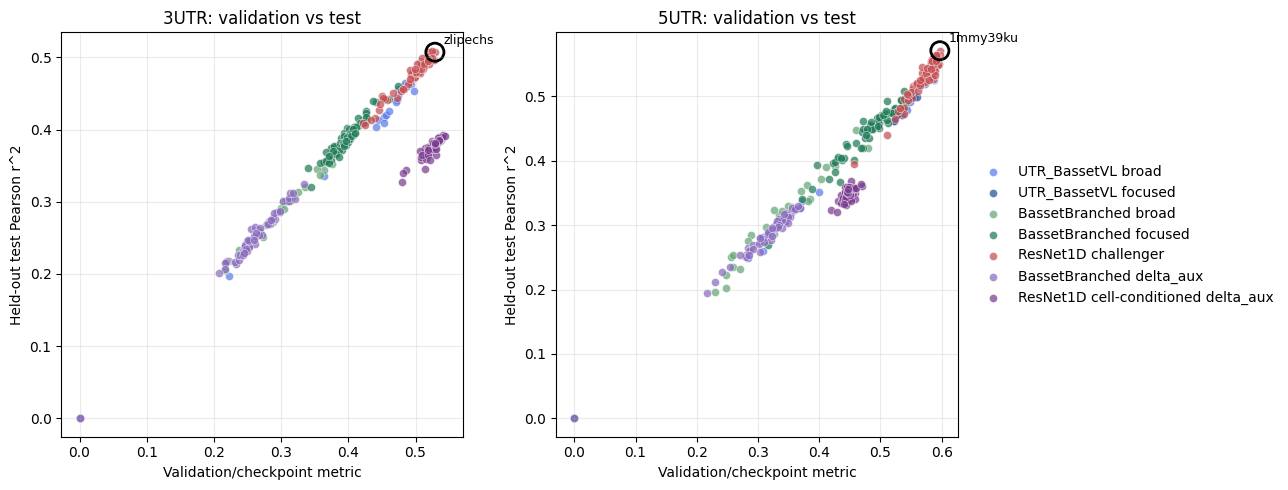

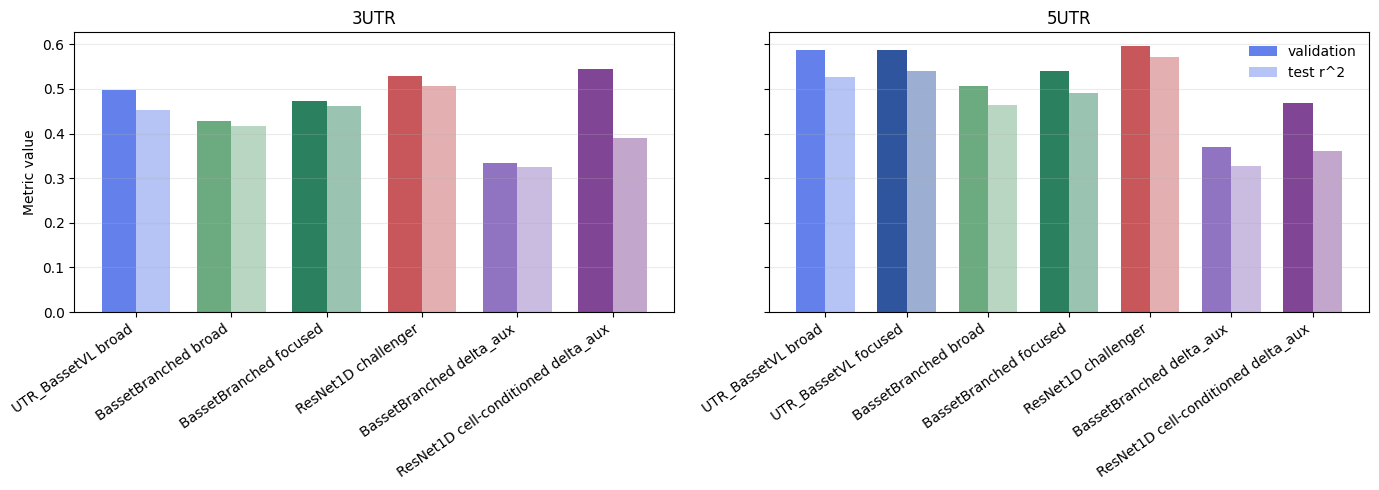

In [19]:
variant_order = [
    'UTR_BassetVL broad', 'UTR_BassetVL focused', 'BassetBranched broad',
    'BassetBranched focused', 'ResNet1D challenger', 'ResNet1D focused',
    'BassetBranched delta_aux', 'ResNet1D cell-conditioned delta_aux',
]
variant_colors = {
    'UTR_BassetVL broad': '#5C7AEA',
    'UTR_BassetVL focused': '#244C9A',
    'BassetBranched broad': '#64A678',
    'BassetBranched focused': '#1F7A56',
    'ResNet1D challenger': '#C44E52',
    'ResNet1D focused': '#8F2D35',
    'BassetBranched delta_aux': '#8A6BBE',
    'ResNet1D cell-conditioned delta_aux': '#7A3B8F',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=False, sharey=False)
for ax, region in zip(axes, REGION_ORDER):
    sub = candidates[candidates['region'].eq(region)].copy()
    for variant in variant_order:
        point_df = sub[sub['variant'].eq(variant)]
        if point_df.empty:
            continue
        ax.scatter(
            point_df['best_metric_value'], point_df['test_r2'],
            label=variant, alpha=0.72, s=34, color=variant_colors.get(variant), edgecolor='white', linewidth=0.4,
        )
    win = validation_winners[validation_winners['region'].eq(region)].iloc[0]
    ax.scatter([win['best_metric_value']], [win['test_r2']], s=170, facecolors='none', edgecolors='black', linewidth=2.0)
    ax.annotate(win['run_id'], (win['best_metric_value'], win['test_r2']), xytext=(6, 6), textcoords='offset points', fontsize=9)
    ax.set_title(f'{region}: validation vs test')
    ax.set_xlabel('Validation/checkpoint metric')
    ax.set_ylabel('Held-out test Pearson r^2')
    ax.grid(True, alpha=0.25)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'utr_hani_decision_validation_vs_test_scatter_may2026.png', dpi=180, bbox_inches='tight')
plt.show()

best_by_variant = best_by(candidates, ['region', 'variant', 'family'], 'best_metric_value', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, region in zip(axes, REGION_ORDER):
    sub = best_by_variant[best_by_variant['region'].eq(region)].copy()
    sub['variant'] = pd.Categorical(sub['variant'], variant_order, ordered=True)
    sub = sub.sort_values('variant')
    x = np.arange(len(sub))
    colors = [variant_colors.get(v, '#777777') for v in sub['variant']]
    ax.bar(x - 0.18, sub['best_metric_value'], width=0.36, label='validation', color=colors, alpha=0.95)
    ax.bar(x + 0.18, sub['test_r2'], width=0.36, label='test r^2', color=colors, alpha=0.45)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['variant'], rotation=35, ha='right')
    ax.set_title(region)
    ax.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('Metric value')
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'utr_hani_decision_best_by_variant_may2026.png', dpi=180, bbox_inches='tight')
plt.show()


### Per-Head and Cell-Conditioned Delta-Aux Diagnostics

,run_id,region,variant,model_module,split,metric,head,cell_type_name,cell_label,value,summary_path
0,zlipechs,3UTR,ResNet1D challenger,ResNet1DRegressor,val,pearson,r2,,r2,0.514377,/home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260507_023429-zlipechs/files/wandb-summary.json
1,zlipechs,3UTR,ResNet1D challenger,ResNet1DRegressor,val,pearson,c1,MDA-MB-231,c1 MDA-MB-231,0.783438,/home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260507_023429-zlipechs/files/wandb-summary.json
2,zlipechs,3UTR,ResNet1D challenger,ResNet1DRegressor,val,pearson,squared_c1,,squared_c1,0.613774,/home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260507_023429-zlipechs/files/wandb-summary.json
3,zlipechs,3UTR,ResNet1D challenger,ResNet1DRegressor,val,spearman,c1,MDA-MB-231,c1 MDA-MB-231,0.783994,/home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260507_023429-zlipechs/files/wandb-summary.json
4,zlipechs,3UTR,ResNet1D challenger,ResNet1DRegressor,val,mse,c1,MDA-MB-231,c1 MDA-MB-231,0.422581,/home/minhang/synBio_AL/boda2_EU/src/learn/wandb/run-20260507_023429-zlipechs/files/wandb-summary.json


cell_label,c1 MDA-MB-231,c2 HepG2,c4 Jurkat,c6 SW480,c13 PA-1,c17 NALM6
label,,,,,,
3UTR ResNet1D challenger zlipechs,0.755,0.759,0.653,0.726,0.662,0.712
5UTR ResNet1D challenger 1mmy39ku,0.783,0.810,0.642,0.791,NaN,0.749


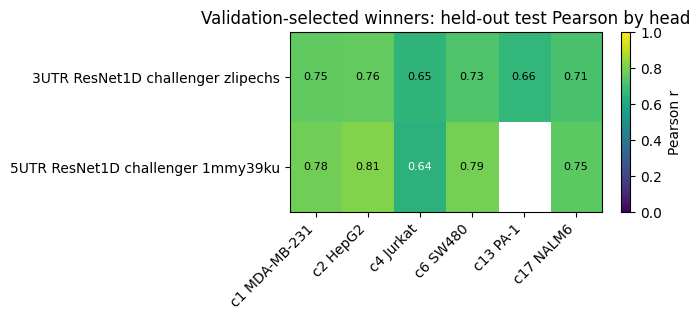

,region,n_runs,completed_runs,expected_runs,sweep_state,best_run_id,best_val_delta_metric,best_mean_val_pearson,best_mean_test_pearson,best_artifact_exists,best_artifact_path
0,3UTR,64,64,64,complete,dnbc0qpp,0.5440,0.6380,0.6171,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/cell_conditioned_delta_aux_bayes/model_artifacts__utr3__hani_rna_...
1,5UTR,64,64,64,complete,15eexb99,0.4691,0.5908,0.5870,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/cell_conditioned_delta_aux_bayes/model_artifacts__utr5__hani_rna_...


,region,run_id,best_metric_value,val_pearson,test_pearson,artifact_exists,artifact_path,test_activity,test_delta,train_activity,train_delta,val_activity,val_delta
0,3UTR,dnbc0qpp,0.5440,0.6380,0.6171,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/cell_conditioned_delta_aux_bayes/model_artifacts__utr3__hani_rna_...,0.7165,0.5178,0.8657,0.6755,0.7345,0.5415
1,5UTR,15eexb99,0.4691,0.5908,0.5870,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/cell_conditioned_delta_aux_bayes/model_artifacts__utr5__hani_rna_...,0.7329,0.4410,0.8684,0.6428,0.7534,0.4282


,region,official_absolute_run_id,official_absolute_variant,official_absolute_val_metric,official_absolute_test_mean_pearson,cell_conditioned_run_id,cell_conditioned_val_delta_metric,cell_conditioned_test_mean_pearson,cell_conditioned_test_delta_pearson,cell_conditioned_test_activity_pearson
0,3UTR,zlipechs,ResNet1D challenger,0.5288,0.7112,dnbc0qpp,0.5440,0.6171,0.5178,0.7165
1,5UTR,1mmy39ku,ResNet1D challenger,0.5971,0.7549,15eexb99,0.4691,0.5870,0.4410,0.7329


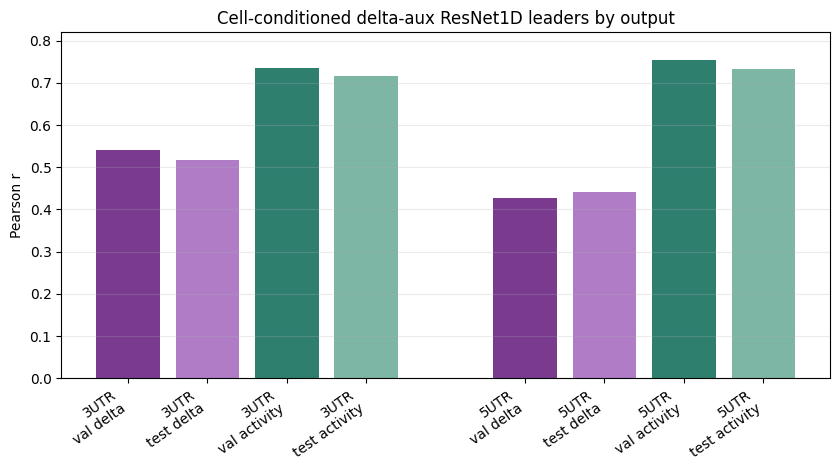

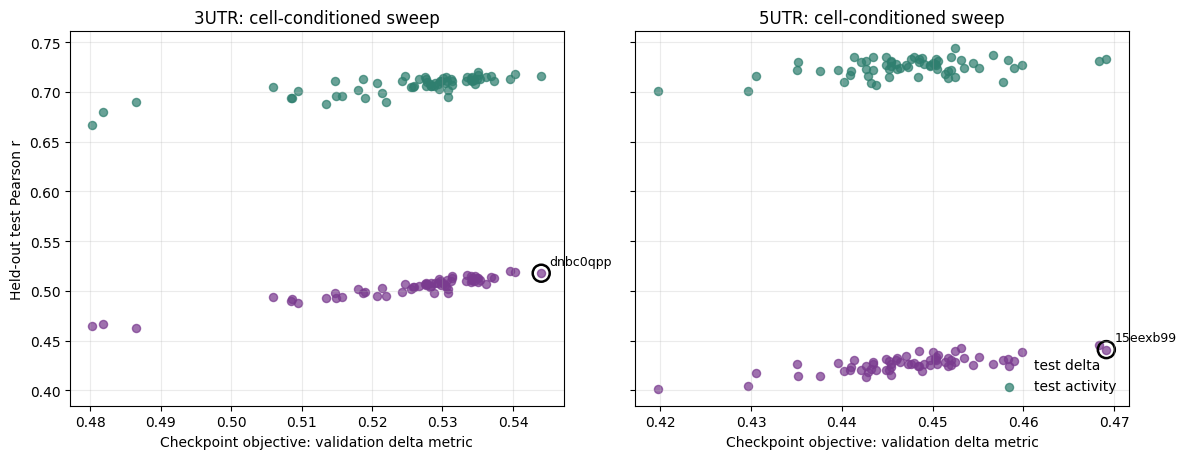

In [20]:
def load_local_summary(run_id):
    matches = sorted(WANDB_ROOT.glob(f'run-*{run_id}/files/wandb-summary.json'))
    if not matches:
        return None, None
    return matches[0], json.loads(matches[0].read_text())


def extract_per_head_rows(run_row):
    summary_path, summary = load_local_summary(run_row['run_id'])
    rows = []
    if summary is None:
        return rows
    pattern = re.compile(r'^(val|test|train)_(pearson|spearman|mse|pearson_squared)_(.+)$')
    for key, value in summary.items():
        match = pattern.match(key)
        if not match:
            continue
        split, metric, head = match.groups()
        if isinstance(value, (int, float)) and math.isfinite(float(value)):
            rows.append({
                'run_id': run_row['run_id'],
                'region': run_row['region'],
                'variant': run_row['variant'],
                'model_module': run_row['model_module'],
                'split': split,
                'metric': metric,
                'head': head,
                'cell_type_name': CELL_TYPE_NAMES.get(head, ''),
                'cell_label': cell_label(head),
                'value': float(value),
                'summary_path': str(summary_path),
            })
    return rows

runs_for_head_diagnostics = pd.concat([
    validation_winners,
    test_leaders,
    delta_winners,
], ignore_index=True).drop_duplicates('run_id')
per_head = pd.DataFrame([
    item
    for _, run_row in runs_for_head_diagnostics.iterrows()
    for item in extract_per_head_rows(run_row)
])

if per_head.empty:
    print('No local per-head W&B summaries found for selected diagnostic runs.')
else:
    per_head.to_csv(OUT_DIR / 'utr_hani_decision_selected_run_per_head_metrics_may2026.csv', index=False)
    display(per_head.head())
    pearson = per_head[
        per_head['split'].eq('test')
        & per_head['metric'].eq('pearson')
        & per_head['head'].isin(CELL_TYPE_NAMES)
    ].copy()
    official_ids = set(validation_winners['run_id'])
    heat_df = pearson[pearson['run_id'].isin(official_ids)].copy()
    heat_df['label'] = heat_df['region'].astype(str) + ' ' + heat_df['variant'] + ' ' + heat_df['run_id']
    matrix = heat_df.pivot_table(index='label', columns='cell_label', values='value', aggfunc='first')
    ordered_cols = [cell_label(head) for head in CELL_ORDER if cell_label(head) in matrix.columns]
    matrix = matrix.reindex(columns=ordered_cols)
    display(matrix.round(3))

    if not matrix.empty:
        fig, ax = plt.subplots(figsize=(max(7, 0.65 * len(matrix.columns)), 2.2 + 0.55 * len(matrix)))
        values = matrix.to_numpy(dtype=float)
        image = ax.imshow(values, aspect='auto', vmin=0.0, vmax=1.0, cmap='viridis')
        ax.set_xticks(np.arange(len(matrix.columns)))
        ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(matrix.index)))
        ax.set_yticklabels(matrix.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', color='white' if values[i, j] < 0.65 else 'black', fontsize=8)
        ax.set_title('Validation-selected winners: held-out test Pearson by head')
        fig.colorbar(image, ax=ax, label='Pearson r')
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'utr_hani_decision_per_head_heatmap_may2026.png', dpi=180, bbox_inches='tight')
        plt.show()

cell_conditioned_status_rows = []
if cell_conditioned_pool.empty:
    print('No cell-conditioned delta-aux ResNet1D runs found yet.')
    cell_conditioned_status = pd.DataFrame()
    cell_conditioned_leader_metrics = pd.DataFrame()
else:
    for region, group in cell_conditioned_pool.groupby('region', observed=True):
        best = group.dropna(subset=['best_metric_value']).sort_values(
            ['best_metric_value', 'timestamp'], ascending=[False, False]
        ).iloc[0]
        cell_conditioned_status_rows.append({
            'region': region,
            'n_runs': len(group),
            'completed_runs': int(group['status'].eq('completed').sum()),
            'expected_runs': EXPECTED_CELL_CONDITIONED_RUNS,
            'sweep_state': 'complete' if int(group['status'].eq('completed').sum()) >= EXPECTED_CELL_CONDITIONED_RUNS else 'partial',
            'best_run_id': best['run_id'],
            'best_val_delta_metric': best['best_metric_value'],
            'best_mean_val_pearson': best['val_pearson'],
            'best_mean_test_pearson': best['test_pearson'],
            'best_artifact_exists': best['artifact_exists'],
            'best_artifact_path': best['artifact_path'],
        })
    cell_conditioned_status = pd.DataFrame(cell_conditioned_status_rows).sort_values('region')
    display(cell_conditioned_status.round(4))
    cell_conditioned_status.to_csv(OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_sweep_status_may2026.csv', index=False)


def extract_delta_aux_output_rows(run_row):
    summary_path, summary = load_local_summary(run_row['run_id'])
    rows = []
    if summary is None:
        return rows
    pattern = re.compile(r'^(val|test|train)_(pearson|spearman|mse|pearson_squared)_(delta|activity)$')
    for key, value in summary.items():
        match = pattern.match(key)
        if not match:
            continue
        split, metric, output = match.groups()
        if isinstance(value, (int, float)) and math.isfinite(float(value)):
            rows.append({
                'run_id': run_row['run_id'],
                'region': run_row['region'],
                'variant': run_row['variant'],
                'split': split,
                'metric': metric,
                'output': output,
                'value': float(value),
                'summary_path': str(summary_path),
            })
    return rows

cell_conditioned_output_metrics = pd.DataFrame([
    item
    for _, run_row in cell_conditioned_pool.iterrows()
    for item in extract_delta_aux_output_rows(run_row)
])
if not cell_conditioned_output_metrics.empty:
    cell_conditioned_output_metrics.to_csv(
        OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_output_metrics_may2026.csv',
        index=False,
    )

cell_conditioned_leader_metrics = pd.DataFrame()
if not cell_conditioned_winners.empty and not cell_conditioned_output_metrics.empty:
    leader_ids = set(cell_conditioned_winners['run_id'])
    leader_output_metrics = cell_conditioned_output_metrics[cell_conditioned_output_metrics['run_id'].isin(leader_ids)].copy()
    cell_conditioned_leader_metrics = (
        leader_output_metrics[leader_output_metrics['metric'].eq('pearson')]
        .pivot_table(index=['region', 'run_id'], columns=['split', 'output'], values='value', aggfunc='first')
        .reset_index()
    )
    cell_conditioned_leader_metrics.columns = [
        '_'.join([str(part) for part in column if part]) if isinstance(column, tuple) else column
        for column in cell_conditioned_leader_metrics.columns
    ]
    leader_context = cell_conditioned_winners[[
        'region', 'run_id', 'best_metric_value', 'val_pearson', 'test_pearson', 'artifact_exists', 'artifact_path'
    ]].copy()
    cell_conditioned_leader_metrics = leader_context.merge(cell_conditioned_leader_metrics, on=['region', 'run_id'], how='left')
    display(cell_conditioned_leader_metrics.round(4))
    cell_conditioned_leader_metrics.to_csv(
        OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_leader_metrics_may2026.csv',
        index=False,
    )

    official_vs_cell_conditioned = validation_winners[[
        'region', 'run_id', 'variant', 'best_metric_value', 'test_pearson'
    ]].rename(columns={
        'run_id': 'official_absolute_run_id',
        'variant': 'official_absolute_variant',
        'best_metric_value': 'official_absolute_val_metric',
        'test_pearson': 'official_absolute_test_mean_pearson',
    }).merge(
        cell_conditioned_leader_metrics[[
            'region', 'run_id', 'best_metric_value', 'test_pearson', 'test_delta', 'test_activity'
        ]].rename(columns={
            'run_id': 'cell_conditioned_run_id',
            'best_metric_value': 'cell_conditioned_val_delta_metric',
            'test_pearson': 'cell_conditioned_test_mean_pearson',
            'test_delta': 'cell_conditioned_test_delta_pearson',
            'test_activity': 'cell_conditioned_test_activity_pearson',
        }),
        on='region',
        how='left',
    )
    display(official_vs_cell_conditioned.round(4))
    official_vs_cell_conditioned.to_csv(
        OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_vs_official_absolute_may2026.csv',
        index=False,
    )

    plot_rows = []
    for _, row in cell_conditioned_leader_metrics.iterrows():
        for split in ['val', 'test']:
            for output in ['delta', 'activity']:
                value = row.get(f'{split}_{output}')
                if pd.notna(value):
                    plot_rows.append({'region': row['region'], 'run_id': row['run_id'], 'split': split, 'output': output, 'pearson': value})
    leader_plot = pd.DataFrame(plot_rows)
    if not leader_plot.empty:
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        labels = []
        x = []
        colors = []
        values = []
        color_map = {('val', 'delta'): '#7A3B8F', ('test', 'delta'): '#B07CC6', ('val', 'activity'): '#2F7F6F', ('test', 'activity'): '#7DB6A4'}
        for ridx, region in enumerate(REGION_ORDER):
            sub = leader_plot[leader_plot['region'].eq(region)]
            for j, (split, output) in enumerate([('val', 'delta'), ('test', 'delta'), ('val', 'activity'), ('test', 'activity')]):
                match = sub[sub['split'].eq(split) & sub['output'].eq(output)]
                if match.empty:
                    continue
                x.append(ridx * 5 + j)
                values.append(float(match['pearson'].iloc[0]))
                labels.append(f'{region}\n{split} {output}')
                colors.append(color_map[(split, output)])
        ax.bar(x, values, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha='right')
        ax.set_ylim(0, max(0.82, max(values) + 0.05))
        ax.set_ylabel('Pearson r')
        ax.set_title('Cell-conditioned delta-aux ResNet1D leaders by output')
        ax.grid(axis='y', alpha=0.25)
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_leader_output_pearson_may2026.png', dpi=180, bbox_inches='tight')
        plt.show()

if not cell_conditioned_output_metrics.empty:
    scatter_base = cell_conditioned_output_metrics[
        cell_conditioned_output_metrics['metric'].eq('pearson')
        & cell_conditioned_output_metrics['split'].eq('test')
        & cell_conditioned_output_metrics['output'].isin(['delta', 'activity'])
    ].pivot_table(index=['region', 'run_id'], columns='output', values='value', aggfunc='first').reset_index()
    scatter_base = scatter_base.merge(
        cell_conditioned_pool[['region', 'run_id', 'best_metric_value']],
        on=['region', 'run_id'],
        how='left',
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharey=True)
    for ax, region in zip(axes, REGION_ORDER):
        sub = scatter_base[scatter_base['region'].eq(region)]
        if sub.empty:
            ax.set_title(f'{region}: no runs yet')
            ax.axis('off')
            continue
        ax.scatter(sub['best_metric_value'], sub['delta'], label='test delta', color='#7A3B8F', alpha=0.72, s=34)
        ax.scatter(sub['best_metric_value'], sub['activity'], label='test activity', color='#2F7F6F', alpha=0.72, s=34)
        win = cell_conditioned_winners[cell_conditioned_winners['region'].eq(region)]
        if not win.empty:
            winner_id = win.iloc[0]['run_id']
            winner_points = sub[sub['run_id'].eq(winner_id)]
            if not winner_points.empty:
                ax.scatter(winner_points['best_metric_value'], winner_points['delta'], s=150, facecolors='none', edgecolors='black', linewidth=1.8)
                ax.annotate(winner_id, (winner_points['best_metric_value'].iloc[0], winner_points['delta'].iloc[0]), xytext=(6, 6), textcoords='offset points', fontsize=9)
        ax.set_xlabel('Checkpoint objective: validation delta metric')
        ax.set_title(f'{region}: cell-conditioned sweep')
        ax.grid(alpha=0.25)
    axes[0].set_ylabel('Held-out test Pearson r')
    axes[1].legend(frameon=False, loc='lower right')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'utr_hani_cell_conditioned_delta_aux_val_delta_vs_test_outputs_may2026.png', dpi=180, bbox_inches='tight')
    plt.show()


### Canonical BODA Registry Snapshot

This reproduces the old notebook's promotion-proposal artifact without mutating `best_runs.csv`. It is a guardrail: the current manifest should already point to the validation-selected absolute-activity winners.


In [21]:
def relative_to_learn(path_value):
    if not isinstance(path_value, str) or not path_value:
        return ''
    path = Path(path_value)
    try:
        return str(path.relative_to(LEARN_ROOT))
    except Exception:
        return path_value


def dataset_name_for_region(region):
    return {
        '3UTR': '3UTR_lib1_branched_observed_heads',
        '5UTR': '5UTR_lib1_branched_observed_heads',
    }[str(region)]

proposal_rows = []
for _, row in validation_winners.sort_values('region').iterrows():
    proposal_rows.append({
        'registry_status': 'current',
        'task_family': row['task_family'],
        'target_family': row['target_family'],
        'dataset_name': dataset_name_for_region(row['region']),
        'comparison_group': row['comparison_group'],
        'source_kind': 'run_registry_validation_selected',
        'wandb_entity': row['wandb_entity'],
        'wandb_project': row['wandb_project'],
        'sweep_id': row['wandb_sweep_id'],
        'run_id': row['run_id'],
        'timestamp': row['timestamp'].strftime('%Y%m%d_%H%M%S') if pd.notna(row['timestamp']) else '',
        'config_path': relative_to_learn(row['config_path']),
        'launch_script': row['launch_script'],
        'model_module': row['model_module'],
        'graph_module': row['graph_module'],
        'metric_name': row['best_metric_name'],
        'metric_value': f"{row['best_metric_value']:.16g}",
        'artifact_path': row['artifact_path'],
        'model_saved_path': row['artifact_path'],
        'notes': (
            'Validation-first May 2026 UTR decision. '
            f"Held-out test_r2={row['test_r2']:.4f}; test_pearson={row['test_pearson']:.4f}. "
            'Delta-aux variants are analyzed as PARADE-style ablations and not promoted as primary pretrained models.'
        ),
    })

proposal = pd.DataFrame(proposal_rows)
proposal_path = OUT_DIR / 'utr_hani_pretrained_model_promotion_proposal_may2026.csv'
proposal.to_csv(proposal_path, index=False)
display(proposal)

current_manifest = pd.read_csv(BEST_RUNS_CSV)
current_manifest = current_manifest[
    current_manifest['registry_status'].eq('current')
    & current_manifest['task_family'].isin(['utr3', 'utr5'])
    & current_manifest['target_family'].eq('hani_rna_activity')
].copy()
manifest_check = proposal[['task_family', 'target_family', 'run_id', 'metric_value', 'artifact_path']].merge(
    current_manifest[['task_family', 'target_family', 'run_id', 'metric_value', 'artifact_path']].rename(columns={
        'run_id': 'manifest_run_id',
        'metric_value': 'manifest_metric_value',
        'artifact_path': 'manifest_artifact_path',
    }),
    on=['task_family', 'target_family'],
    how='left',
)
manifest_check['manifest_matches_validation_selection'] = manifest_check['run_id'].eq(manifest_check['manifest_run_id'])
manifest_check['artifact_exists'] = manifest_check['artifact_path'].map(lambda value: Path(str(value)).exists())
display(manifest_check)
manifest_check.to_csv(OUT_DIR / 'utr_hani_current_best_runs_manifest_check_may2026.csv', index=False)
print(f'Wrote {proposal_path}')


,registry_status,task_family,target_family,dataset_name,comparison_group,source_kind,wandb_entity,wandb_project,sweep_id,run_id,timestamp,config_path,launch_script,model_module,graph_module,metric_name,metric_value,artifact_path,model_saved_path,notes
0,current,utr3,hani_rna_activity,3UTR_lib1_branched_observed_heads,utr3__hani_rna_activity__observed_head_resnet1d_challenger,run_registry_validation_selected,minhangxu1998-baylor-college-of-medicine,utr3__hani_rna_activity__resnet1d_challenger,i25qb8e3,zlipechs,20260507_024609,configs/utr3/hani_rna_activity/resnet1d/utr3__hani_rna_activity__resnet1d__bayes.yml,launch/utr3_hani_resnet1d_sweep.sh,ResNet1DRegressor,CNNBasicTraining,epoch_end_val_pearson_r2,0.5288228988647461,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...,Validation-first May 2026 UTR decision. Held-out test_r2=0.5071; test_pearson=0.7112. Delta-aux variants are analyzed as PARADE-style ablations and not prom...
1,current,utr5,hani_rna_activity,5UTR_lib1_branched_observed_heads,utr5__hani_rna_activity__observed_head_resnet1d_challenger,run_registry_validation_selected,minhangxu1998-baylor-college-of-medicine,utr5__hani_rna_activity__resnet1d_challenger,9fpbes2j,1mmy39ku,20260508_153215,configs/utr5/hani_rna_activity/resnet1d/utr5__hani_rna_activity__resnet1d__bayes.yml,launch/utr5_hani_resnet1d_sweep.sh,ResNet1DRegressor,CNNBasicTraining,epoch_end_val_pearson_r2,0.5970736145973206,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...,Validation-first May 2026 UTR decision. Held-out test_r2=0.5708; test_pearson=0.7549. Delta-aux variants are analyzed as PARADE-style ablations and not prom...


,task_family,target_family,run_id,metric_value,artifact_path,manifest_run_id,manifest_metric_value,manifest_artifact_path,manifest_matches_validation_selection,artifact_exists
0,utr3,hani_rna_activity,zlipechs,0.5288228988647461,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...,zlipechs,0.528823,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...,True,True
1,utr5,hani_rna_activity,1mmy39ku,0.5970736145973206,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...,1mmy39ku,0.597074,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...,True,True


Wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/parade_released_checkpoint_eval_may2026/utr_hani_pretrained_model_promotion_proposal_may2026.csv


## Load Hani/Goodarzi Lib1 and Lib2 Truth Tables

In [22]:
def coerce_bins(df):
    df = df.copy()
    for col in BIN_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def aggregate_processed_library(path, heads):
    df = pd.read_csv(path)
    df = coerce_bins(df)
    keep = df[df['cell_type'].isin(heads)].dropna(subset=['seq', 'cell_type'] + BIN_COLUMNS).copy()
    group_cols = ['seq', 'cell_type'] + (['fold'] if 'fold' in keep.columns else [])
    grouped = keep.groupby(group_cols, observed=True)[BIN_COLUMNS].sum().reset_index()
    denom = grouped[BIN_COLUMNS].sum(axis=1)
    grouped = grouped[denom > 0].copy()
    denom = denom[denom > 0]
    grouped['rna_activity'] = (
        grouped['1'] + 2.0 * grouped['2'] + 3.0 * grouped['3'] + 4.0 * grouped['4']
    ) / denom
    index_cols = ['seq'] + (['fold'] if 'fold' in grouped.columns else [])
    wide = grouped.pivot_table(index=index_cols, columns='cell_type', values='rna_activity', aggfunc='first').reset_index()
    for head in heads:
        if head not in wide.columns:
            wide[head] = np.nan
    return wide[['seq'] + (['fold'] if 'fold' in wide.columns else []) + list(heads)]


def load_truth_sets():
    truth_sets = {}
    train_stats = {}
    for region in REGION_ORDER:
        lib1_wide = pd.read_csv(DATA_DIR / f'{region}_lib1_branched_observed_heads.csv')
        heads = BODA_HEADS[region]
        for head in heads:
            lib1_wide[head] = pd.to_numeric(lib1_wide[head], errors='coerce')
        train = lib1_wide[lib1_wide['fold'].eq('train')].copy()
        train_stats[region] = {
            'means': train[heads].mean(),
            'stds': train[heads].std().replace(0, 1.0),
        }
        truth_sets[(region, 'lib1_test')] = lib1_wide[lib1_wide['fold'].eq('test')].reset_index(drop=True)
        lib2 = aggregate_processed_library(DATA_DIR / f'{region}_lib2_processed.csv', PARADE_PREDICT_HEADS[region])
        truth_sets[(region, 'lib2_overlap')] = lib2.reset_index(drop=True)
    return truth_sets, train_stats

truth_sets, train_stats = load_truth_sets()
summary_rows = []
for (region, split), df in truth_sets.items():
    heads = [h for h in CELL_ORDER if h in df.columns]
    summary_rows.append({
        'region': region,
        'split': split,
        'n_sequences': len(df),
        'available_heads': ','.join([h for h in heads if df[h].notna().sum() >= 2]),
        'insert_lengths': ','.join(map(str, sorted(df['seq'].astype(str).str.len().unique())[:8])),
    })
truth_summary = pd.DataFrame(summary_rows)
truth_summary.to_csv(OUT_DIR / 'truth_set_summary.csv', index=False)
display(truth_summary)


,region,split,n_sequences,available_heads,insert_lengths
0,3UTR,lib1_test,2842,"c1,c2,c4,c6,c13,c17",240
1,3UTR,lib2_overlap,9373,"c1,c2,c4,c6,c17",240
2,5UTR,lib1_test,2160,"c1,c2,c4,c6,c17",50
3,5UTR,lib2_overlap,11368,"c1,c2,c4,c6,c17",50


## Scoring Helpers

In [23]:
def common_heads_for_eval(truth_df, pred_df, preferred_heads):
    heads = []
    for head in preferred_heads:
        if head not in truth_df.columns or head not in pred_df.columns:
            continue
        true_count = pd.to_numeric(truth_df[head], errors='coerce').notna().sum()
        pred_count = pd.to_numeric(pred_df[head], errors='coerce').notna().sum()
        if true_count >= 2 and pred_count >= 2:
            heads.append(head)
    return heads


def align_prediction_to_truth(pred_df, truth_df):
    pred = pred_df.copy()
    if pred.index.name != 'seq':
        pred.index.name = 'seq'
    truth = truth_df.copy().set_index('seq', drop=False)
    pred = pred.reindex(truth.index)
    return pred, truth


def score_activity_predictions(model_label, source, region, split, pred_activity, truth_df, preferred_heads, pred_delta=None):
    pred_activity, truth = align_prediction_to_truth(pred_activity, truth_df)
    heads = common_heads_for_eval(truth, pred_activity, preferred_heads)
    if not heads:
        return [], []

    valid_rows = pred_activity[heads].notna().all(axis=1) & truth[heads].notna().all(axis=1)
    pred_valid = pred_activity.loc[valid_rows, heads].astype(float)
    truth_valid = truth.loc[valid_rows, heads].astype(float)

    per_cell_rows = []
    pearsons = []
    for head in heads:
        # Use the same complete-case sequence set as the paper-style average metric.
        # This reproduces the author benchmark rows and avoids mixing metric definitions.
        r = pearson_np(pred_valid[head], truth_valid[head])
        pearsons.append(r)
        per_cell_rows.append({
            'model_label': model_label,
            'source': source,
            'region': region,
            'split': split,
            'metric': 'activity_pearson',
            'head': head,
            'cell_label': cell_label(head),
            'value': r,
            'n_sequences': int(valid_rows.sum()),
        })
    avg_r = pearson_np(pred_valid.mean(axis=1), truth_valid.mean(axis=1))
    flat_r = pearson_np(pred_valid.to_numpy().ravel(), truth_valid.to_numpy().ravel())
    summary_rows = [{
        'model_label': model_label,
        'source': source,
        'region': region,
        'split': split,
        'target': 'activity',
        'n_sequences': int(valid_rows.sum()),
        'heads_used': ','.join(heads),
        'n_heads': len(heads),
        'mean_per_cell_pearson': float(np.nanmean(pearsons)) if len(pearsons) else np.nan,
        'average_activity_pearson': avg_r,
        'flattened_activity_pearson': flat_r,
    }]

    if pred_delta is not None:
        pred_delta, truth_for_delta = align_prediction_to_truth(pred_delta, truth_df)
        delta_heads = common_heads_for_eval(truth_for_delta, pred_delta, heads)
        if delta_heads:
            valid_delta_rows = pred_delta[delta_heads].notna().all(axis=1) & truth_for_delta[delta_heads].notna().all(axis=1)
            true_delta = truth_for_delta.loc[valid_delta_rows, delta_heads].astype(float)
            true_delta = true_delta.sub(true_delta.mean(axis=1), axis=0)
            pred_delta_valid = pred_delta.loc[valid_delta_rows, delta_heads].astype(float)
            delta_rs = []
            for head in delta_heads:
                r = pearson_np(pred_delta_valid[head], true_delta[head])
                delta_rs.append(r)
                per_cell_rows.append({
                    'model_label': model_label,
                    'source': source,
                    'region': region,
                    'split': split,
                    'metric': 'delta_pearson',
                    'head': head,
                    'cell_label': cell_label(head),
                    'value': r,
                    'n_sequences': int(valid_delta_rows.sum()),
                })
            summary_rows.append({
                'model_label': model_label,
                'source': source,
                'region': region,
                'split': split,
                'target': 'delta',
                'n_sequences': int(valid_delta_rows.sum()),
                'heads_used': ','.join(delta_heads),
                'n_heads': len(delta_heads),
                'mean_per_cell_pearson': float(np.nanmean(delta_rs)) if len(delta_rs) else np.nan,
                'average_activity_pearson': np.nan,
                'flattened_activity_pearson': pearson_np(pred_delta_valid.to_numpy().ravel(), true_delta.to_numpy().ravel()),
            })

    return summary_rows, per_cell_rows


def author_reference_rows():
    summary_rows = []
    per_cell_rows = []
    for (region, split), values in AUTHOR_PARADE_VALUES.items():
        head_values = {k: v for k, v in values.items() if k.startswith('c')}
        for head, value in head_values.items():
            per_cell_rows.append({
                'model_label': 'PARADE authors notebook',
                'source': 'author_reported_public_notebook',
                'region': region,
                'split': split,
                'metric': 'activity_pearson',
                'head': head,
                'cell_label': cell_label(head),
                'value': float(value),
                'n_sequences': np.nan,
            })
        summary_rows.append({
            'model_label': 'PARADE authors notebook',
            'source': 'author_reported_public_notebook',
            'region': region,
            'split': split,
            'target': 'activity',
            'n_sequences': np.nan,
            'heads_used': ','.join(sorted(head_values, key=cell_sort_key)),
            'n_heads': len(head_values),
            'mean_per_cell_pearson': float(np.mean(list(head_values.values()))),
            'average_activity_pearson': float(values['average_activity_pearson']),
            'flattened_activity_pearson': np.nan,
        })
    return summary_rows, per_cell_rows


## Released PARADE Checkpoint Inference

In [24]:
def import_parade_stack():
    model_dir = str(PARADE_MODEL_DIR)
    if model_dir not in sys.path:
        sys.path.insert(0, model_dir)
    from torch.utils.data import DataLoader
    from pl_regressor import RNARegressor
    from utrdata_cl import UTRData
    return DataLoader, RNARegressor, UTRData


def load_parade_model(region, device):
    _, RNARegressor, _ = import_parade_stack()
    ckpt_path = PARADE_CKPTS[region]
    model = RNARegressor.load_from_checkpoint(str(ckpt_path), map_location='cpu')
    model.eval()
    model.to(device)
    return model


def predict_parade_activity_delta(seqs, region, heads, device=DEVICE, batch_size=PARADE_BATCH_SIZE, num_workers=NUM_WORKERS):
    DataLoader, _, UTRData = import_parade_stack()
    records = []
    for idx, seq in enumerate(seqs):
        seq_key = str(seq)
        seq_model = seq_key.upper()
        for head in heads:
            records.append({'id': idx, 'seq_key': seq_key, 'seq': seq_model, 'cell_type': head})
    ds_frame = pd.DataFrame(records)
    construct_type = 'utr3' if region == '3UTR' else 'utr5'
    ds = UTRData(
        df=ds_frame,
        predict_cols=[],
        construct_type=construct_type,
        features=('sequence', 'positional', 'conditions'),
        augment=False,
        augment_test_time=False,
        augment_kws={
            'extend_left': 0,
            'extend_right': 0,
            'shift_left': 0,
            'shift_right': 0,
            'revcomp': False,
        },
    )
    dl = DataLoader(ds, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False)
    model = load_parade_model(region, device)
    preds = []
    with torch.no_grad():
        for batch in dl:
            x = batch[0].to(device).float()
            y = model.model(x).detach().cpu()
            preds.append(y)
    pred = torch.cat(preds, dim=0).numpy()
    ds_frame['pred_delta'] = pred[:, 0]
    ds_frame['pred_activity'] = pred[:, 1]
    activity = ds_frame.pivot_table(index='seq_key', columns='cell_type', values='pred_activity', aggfunc='first')
    delta = ds_frame.pivot_table(index='seq_key', columns='cell_type', values='pred_delta', aggfunc='first')
    activity = activity.reindex(columns=heads)
    delta = delta.reindex(columns=heads)
    activity.index.name = 'seq'
    delta.index.name = 'seq'
    return activity, delta


def load_or_predict_parade(region, split, seqs, heads):
    safe_split = re.sub('[^A-Za-z0-9_]+', '_', split)
    activity_path = OUT_DIR / f'parade_released_{region}_{safe_split}_activity_predictions.csv'
    delta_path = OUT_DIR / f'parade_released_{region}_{safe_split}_delta_predictions.csv'
    if activity_path.exists() and delta_path.exists() and not OVERWRITE:
        activity = pd.read_csv(activity_path, index_col='seq')
        delta = pd.read_csv(delta_path, index_col='seq')
        return activity, delta
    print(f'Predicting PARADE released checkpoint: {region} {split} ({len(seqs)} sequences)')
    activity, delta = predict_parade_activity_delta(seqs, region, heads)
    activity.to_csv(activity_path)
    delta.to_csv(delta_path)
    return activity, delta

# Smoke-test checkpoint loading without doing full prediction.
for region in REGION_ORDER:
    model = load_parade_model(region, DEVICE)
    print(region, 'params', sum(p.numel() for p in model.parameters()), 'hparams', dict(model.hparams.model_kws))
    del model
if DEVICE.startswith('cuda'):
    torch.cuda.empty_cache()


/home/minhang/miniconda3/envs/boda_env/lib/python3.7/site-packages/pytorch_lightning/utilities/migration/utils.py:52: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.2, which is newer than your current Lightning version: v1.9.5
  category=PossibleUserWarning,


3UTR params 269066 hparams {'seqsize': 240, 'in_channels': 12, 'ks': 3, 'out_channels': 2, 'conv_sizes': (128, 64, 64, 32, 32), 'mapper_size': 256, 'linear_sizes': None, 'use_max_pooling': False, 'final_activation': <class 'torch.nn.modules.linear.Identity'>}
5UTR params 268298 hparams {'seqsize': 50, 'in_channels': 10, 'ks': 3, 'out_channels': 2, 'conv_sizes': (128, 64, 64, 32, 32), 'mapper_size': 256, 'linear_sizes': None, 'use_max_pooling': False, 'final_activation': <class 'torch.nn.modules.linear.Identity'>}


## Current BODA Model Inference

In [25]:
def safe_extract(tar, target_dir):
    target_root = target_dir.resolve()
    for member in tar.getmembers():
        member_path = (target_dir / member.name).resolve()
        if os.path.commonpath([str(target_root), str(member_path)]) != str(target_root):
            raise RuntimeError(f'Unsafe path in tarball: {member.name}')
    tar.extractall(str(target_dir))


def import_boda_stack():
    repo_root = str(REPO_ROOT)
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from torch.utils.data import DataLoader, TensorDataset
    import boda
    from boda.common import utils as boda_utils
    return DataLoader, TensorDataset, boda, boda_utils


def load_boda_artifact_model(artifact_path):
    DataLoader, TensorDataset, boda, boda_utils = import_boda_stack()
    with tempfile.TemporaryDirectory() as tmp:
        tmp_path = Path(tmp)
        with tarfile.open(str(artifact_path)) as tar:
            safe_extract(tar, tmp_path)
        ckpt = torch.load(tmp_path / 'artifacts' / 'torch_checkpoint.pt', map_location='cpu')
    model_module = ckpt['model_module']
    model_cls = getattr(boda.model, model_module)
    model_hparams = vars(ckpt['model_hparams'])
    model = model_cls(**model_hparams)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    model.to(DEVICE)
    data_hparams = vars(ckpt['data_hparams'])
    return model, data_hparams, model_hparams, model_module, DataLoader, TensorDataset, boda_utils


def predict_boda_normalized(model, seqs, batch_size, DataLoader, TensorDataset, boda_utils):
    x = torch.stack([boda_utils.dna2tensor(str(seq).upper()) for seq in seqs])
    ds = TensorDataset(x)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)
    preds = []
    with torch.no_grad():
        for (batch_x,) in dl:
            y = model(batch_x.to(DEVICE)).detach().cpu()
            preds.append(y)
    return torch.cat(preds, dim=0).numpy()


def read_current_boda_rows():
    best = pd.read_csv(BEST_RUNS_CSV)
    rows = best[
        best['registry_status'].eq('current')
        & best['task_family'].isin(['utr3', 'utr5'])
        & best['target_family'].eq('hani_rna_activity')
    ].copy()
    rows['region'] = rows['task_family'].map({'utr3': '3UTR', 'utr5': '5UTR'})
    rows['model_label'] = rows['region'] + ' BODA current ' + rows['model_module'].astype(str) + ' ' + rows['run_id'].astype(str)
    rows['artifact_exists'] = rows['artifact_path'].map(lambda p: Path(str(p)).exists())
    return rows.sort_values('region').reset_index(drop=True)


def load_or_predict_boda_current(run_row, split, truth_df, train_stats):
    region = run_row['region']
    safe_split = re.sub('[^A-Za-z0-9_]+', '_', split)
    pred_path = OUT_DIR / f'boda_current_{region}_{run_row["run_id"]}_{safe_split}_activity_predictions.csv'
    if pred_path.exists() and not OVERWRITE:
        return pd.read_csv(pred_path, index_col='seq')
    artifact_path = Path(str(run_row['artifact_path']))
    if not artifact_path.exists():
        raise FileNotFoundError(f'Missing BODA artifact: {artifact_path}')
    print(f'Predicting BODA current model: {region} {run_row["run_id"]} {split} ({len(truth_df)} sequences)')
    model, data_hparams, _, _, DataLoader, TensorDataset, boda_utils = load_boda_artifact_model(artifact_path)
    heads = [str(x) for x in as_list(data_hparams['activity_columns'])]
    pred_norm = predict_boda_normalized(model, truth_df['seq'].tolist(), BODA_BATCH_SIZE, DataLoader, TensorDataset, boda_utils)
    pred_norm = pd.DataFrame(pred_norm, columns=heads, index=truth_df['seq'].astype(str))
    means = train_stats[region]['means'].reindex(heads)
    stds = train_stats[region]['stds'].reindex(heads).replace(0, 1.0)
    pred_raw = pred_norm.mul(stds, axis=1).add(means, axis=1)
    pred_raw.index.name = 'seq'
    pred_raw.to_csv(pred_path)
    return pred_raw

current_boda = read_current_boda_rows()
display(current_boda[['region', 'run_id', 'model_module', 'metric_name', 'metric_value', 'artifact_exists', 'artifact_path']])
if not current_boda['artifact_exists'].all():
    raise FileNotFoundError('One or more current BODA artifact tarballs are missing.')


,region,run_id,model_module,metric_name,metric_value,artifact_exists,artifact_path
0,3UTR,zlipechs,ResNet1DRegressor,epoch_end_val_pearson_r2,0.528823,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/hani_rna_activity/resnet1d/bayes/model_artifacts__utr3__hani_rna_activity__resnet1d_challeng...
1,5UTR,1mmy39ku,ResNet1DRegressor,epoch_end_val_pearson_r2,0.597074,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity/resnet1d/bayes/model_artifacts__utr5__hani_rna_activity__resnet1d_challeng...


## Evaluate Lib1 Test and Lib2 Overlap

In [26]:
summary_rows, per_cell_rows = [], []

for (region, split), truth_df in truth_sets.items():
    heads = PARADE_PREDICT_HEADS[region]
    activity, delta = load_or_predict_parade(region, split, truth_df['seq'].tolist(), heads)
    rows, head_rows = score_activity_predictions(
        model_label='PARADE released checkpoint',
        source='local_released_checkpoint',
        region=region,
        split=split,
        pred_activity=activity,
        pred_delta=delta,
        truth_df=truth_df,
        preferred_heads=heads,
    )
    summary_rows.extend(rows)
    per_cell_rows.extend(head_rows)

for _, run_row in current_boda.iterrows():
    region = run_row['region']
    for split in ['lib1_test', 'lib2_overlap']:
        truth_df = truth_sets[(region, split)]
        pred = load_or_predict_boda_current(run_row, split, truth_df, train_stats)
        rows, head_rows = score_activity_predictions(
            model_label=run_row['model_label'],
            source='boda_current_artifact',
            region=region,
            split=split,
            pred_activity=pred,
            pred_delta=None,
            truth_df=truth_df,
            preferred_heads=BODA_HEADS[region],
        )
        summary_rows.extend(rows)
        per_cell_rows.extend(head_rows)

summary_df = pd.DataFrame(summary_rows)
per_cell_df = pd.DataFrame(per_cell_rows)
summary_df.to_csv(OUT_DIR / 'parade_released_vs_boda_current_summary.csv', index=False)
per_cell_df.to_csv(OUT_DIR / 'parade_released_vs_boda_current_per_cell.csv', index=False)

author_summary_rows, author_per_cell_rows = author_reference_rows()
author_summary_df = pd.DataFrame(author_summary_rows)
author_per_cell_df = pd.DataFrame(author_per_cell_rows)
author_summary_df.to_csv(OUT_DIR / 'parade_authors_notebook_reference_summary.csv', index=False)
author_per_cell_df.to_csv(OUT_DIR / 'parade_authors_notebook_reference_per_cell.csv', index=False)

released_summary = summary_df[
    summary_df['model_label'].eq('PARADE released checkpoint')
    & summary_df['target'].eq('activity')
].copy()
parade_checkpoint_agreement = released_summary.merge(
    author_summary_df,
    on=['region', 'split', 'target'],
    how='left',
    suffixes=('_released', '_authors'),
)
for metric in ['average_activity_pearson', 'mean_per_cell_pearson']:
    parade_checkpoint_agreement[f'{metric}_abs_diff'] = (
        parade_checkpoint_agreement[f'{metric}_released'] - parade_checkpoint_agreement[f'{metric}_authors']
    ).abs()
parade_checkpoint_agreement.to_csv(OUT_DIR / 'parade_released_checkpoint_vs_authors_notebook_agreement_summary.csv', index=False)

released_per_cell = per_cell_df[
    per_cell_df['model_label'].eq('PARADE released checkpoint')
    & per_cell_df['metric'].eq('activity_pearson')
].copy()
parade_per_cell_agreement = released_per_cell.merge(
    author_per_cell_df,
    on=['region', 'split', 'metric', 'head'],
    how='left',
    suffixes=('_released', '_authors'),
)
parade_per_cell_agreement['abs_diff'] = (parade_per_cell_agreement['value_released'] - parade_per_cell_agreement['value_authors']).abs()
parade_per_cell_agreement.to_csv(OUT_DIR / 'parade_released_checkpoint_vs_authors_notebook_agreement_per_cell.csv', index=False)

agreement_cols = [
    'region', 'split', 'n_sequences_released', 'heads_used_released',
    'average_activity_pearson_released', 'average_activity_pearson_authors', 'average_activity_pearson_abs_diff',
    'mean_per_cell_pearson_released', 'mean_per_cell_pearson_authors', 'mean_per_cell_pearson_abs_diff',
]
print('Main comparison table: one PARADE series, because the released checkpoints reproduce the authors notebook benchmark values under the same complete-case convention.')
display(summary_df.sort_values(['region', 'split', 'target', 'model_label']).round(4))
print('Checkpoint agreement check against author notebook reference values:')
display(parade_checkpoint_agreement[agreement_cols].round(6))
max_summary_diff = parade_checkpoint_agreement[[
    'average_activity_pearson_abs_diff', 'mean_per_cell_pearson_abs_diff'
]].max().max()
max_cell_diff = parade_per_cell_agreement['abs_diff'].max()
print(f'Max summary abs diff: {max_summary_diff:.6g}; max per-cell abs diff: {max_cell_diff:.6g}')


Main comparison table: one PARADE series, because the released checkpoints reproduce the authors notebook benchmark values under the same complete-case convention.


,model_label,source,region,split,target,n_sequences,heads_used,n_heads,mean_per_cell_pearson,average_activity_pearson,flattened_activity_pearson
8,3UTR BODA current ResNet1DRegressor zlipechs,boda_current_artifact,3UTR,lib1_test,activity,2842,"c1,c2,c4,c6,c13,c17",6,0.7112,0.7985,0.7172
0,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,activity,2842,"c1,c2,c4,c6,c17,c13",6,0.7068,0.7926,0.7146
1,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta,2842,"c1,c2,c4,c6,c17,c13",6,0.4233,NaN,0.4481
9,3UTR BODA current ResNet1DRegressor zlipechs,boda_current_artifact,3UTR,lib2_overlap,activity,5675,"c1,c2,c4,c6,c17",5,0.6357,0.7421,0.6221
2,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,activity,5675,"c1,c2,c4,c6,c17",5,0.6746,0.7673,0.6606
3,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,delta,5675,"c1,c2,c4,c6,c17",5,0.3571,NaN,0.3388
10,5UTR BODA current ResNet1DRegressor 1mmy39ku,boda_current_artifact,5UTR,lib1_test,activity,2160,"c1,c2,c4,c6,c17",5,0.7550,0.8331,0.7497
4,PARADE released checkpoint,local_released_checkpoint,5UTR,lib1_test,activity,2160,"c1,c2,c4,c6,c17",5,0.7467,0.8230,0.7433
5,PARADE released checkpoint,local_released_checkpoint,5UTR,lib1_test,delta,2160,"c1,c2,c4,c6,c17",5,0.3757,NaN,0.3982
11,5UTR BODA current ResNet1DRegressor 1mmy39ku,boda_current_artifact,5UTR,lib2_overlap,activity,10175,"c1,c2,c4,c6,c17",5,0.5406,0.7055,0.5286


Checkpoint agreement check against author notebook reference values:


,region,split,n_sequences_released,heads_used_released,average_activity_pearson_released,average_activity_pearson_authors,average_activity_pearson_abs_diff,mean_per_cell_pearson_released,mean_per_cell_pearson_authors,mean_per_cell_pearson_abs_diff
0,3UTR,lib1_test,2842,"c1,c2,c4,c6,c17,c13",0.792601,0.792601,0.000000,0.706836,0.706836,0.000000
1,3UTR,lib2_overlap,5675,"c1,c2,c4,c6,c17",0.767329,0.767333,0.000004,0.674571,0.674571,0.000001
2,5UTR,lib1_test,2160,"c1,c2,c4,c6,c17",0.823008,0.823008,0.000000,0.746695,0.746695,0.000000
3,5UTR,lib2_overlap,10175,"c1,c2,c4,c6,c17",0.704292,0.704422,0.000130,0.538778,0.538092,0.000686


Max summary abs diff: 0.000685745; max per-cell abs diff: 0.00458617


## Lib1/Lib2 Plots

The plots below show one PARADE series: the released checkpoints. The author-notebook values are retained in the agreement CSV/table above instead of repeated in every figure.


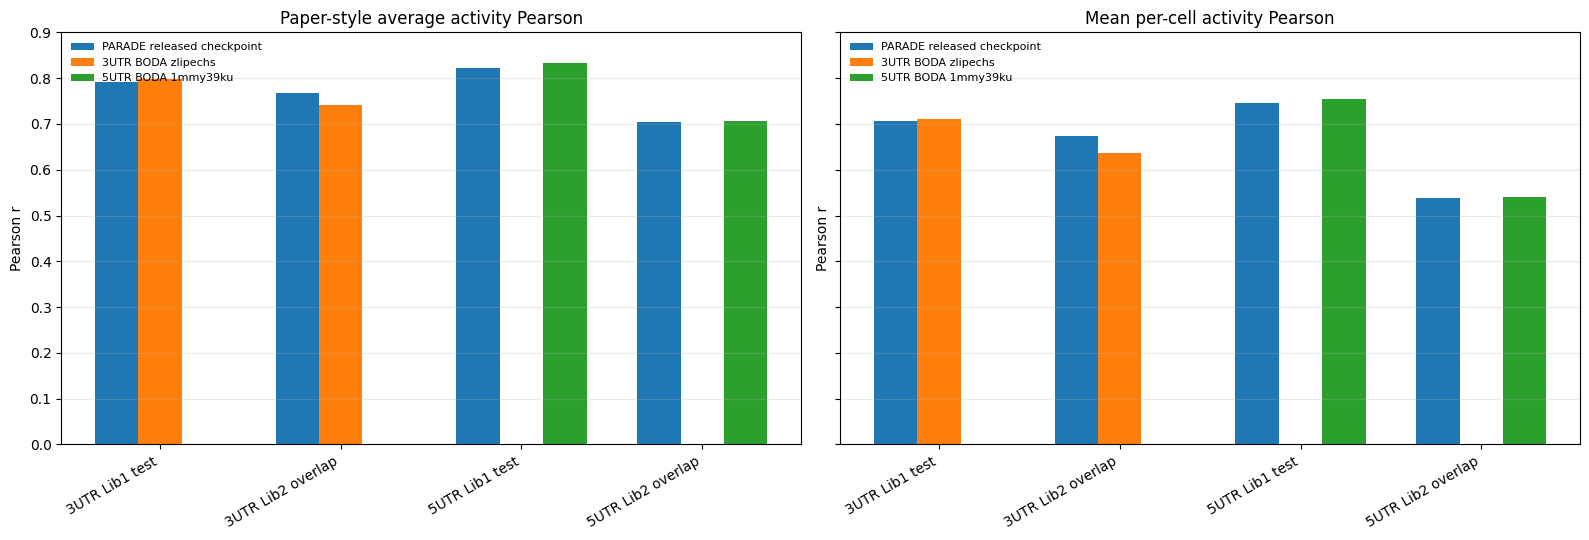

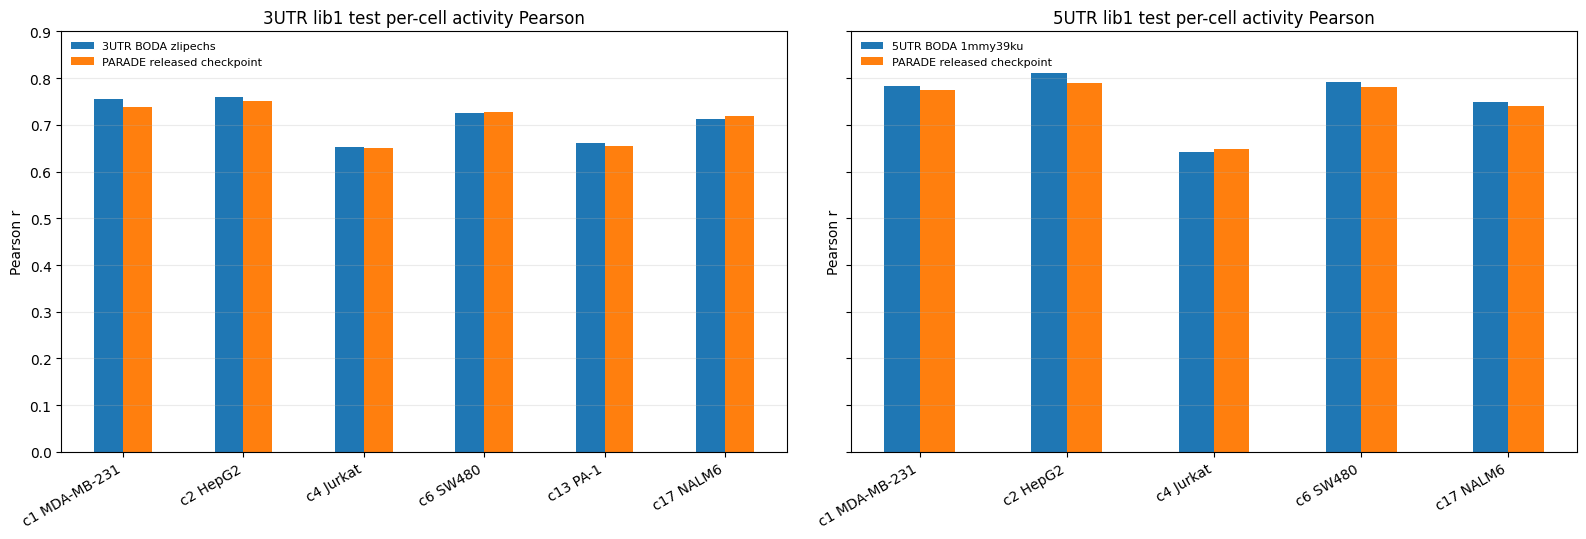

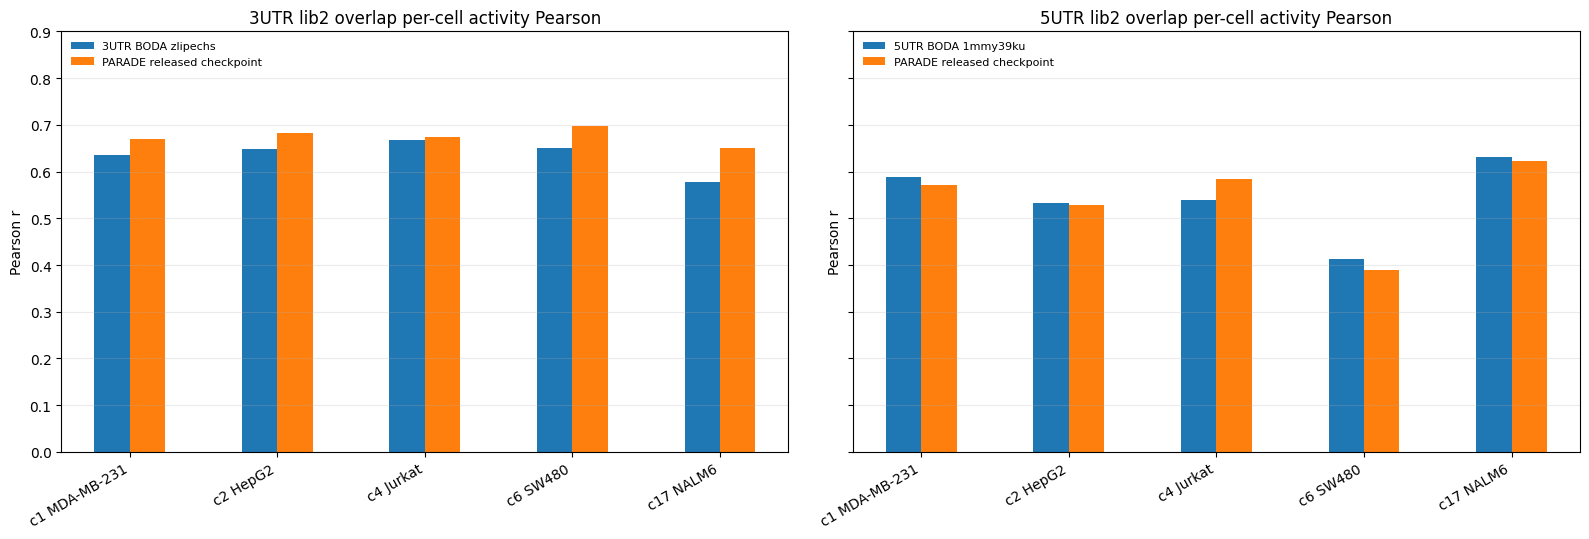

,model_label,source,region,split,metric,head,cell_label,value,n_sequences
6,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c1,c1 MDA-MB-231,0.5277,2842
11,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c13,c13 PA-1,0.5602,2842
10,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c17,c17 NALM6,0.4153,2842
7,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c2,c2 HepG2,0.2759,2842
8,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c4,c4 Jurkat,0.3266,2842
9,PARADE released checkpoint,local_released_checkpoint,3UTR,lib1_test,delta_pearson,c6,c6 SW480,0.4338,2842
17,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,delta_pearson,c1,c1 MDA-MB-231,0.2329,5675
21,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,delta_pearson,c17,c17 NALM6,0.3811,5675
18,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,delta_pearson,c2,c2 HepG2,0.3073,5675
19,PARADE released checkpoint,local_released_checkpoint,3UTR,lib2_overlap,delta_pearson,c4,c4 Jurkat,0.4699,5675


In [27]:
def grouped_barplot(df, x_col, y_col, hue_col, ax, title, y_label='Pearson r', y_lim=(0, 0.9)):
    if df.empty:
        ax.set_axis_off()
        ax.set_title(title)
        return
    x_values = list(dict.fromkeys(df[x_col].tolist()))
    hue_values = list(dict.fromkeys(df[hue_col].tolist()))
    x = np.arange(len(x_values))
    width = min(0.82 / max(len(hue_values), 1), 0.24)
    offsets = (np.arange(len(hue_values)) - (len(hue_values) - 1) / 2.0) * width
    cmap = plt.get_cmap('tab10')
    for i, hue in enumerate(hue_values):
        sub = df[df[hue_col].eq(hue)]
        values = []
        for x_value in x_values:
            series = sub[sub[x_col].eq(x_value)][y_col]
            values.append(float(series.iloc[0]) if len(series) else np.nan)
        ax.bar(x + offsets[i], values, width=width, label=hue, color=cmap(i % 10))
    ax.set_xticks(x)
    ax.set_xticklabels(x_values, rotation=30, ha='right')
    ax.set_ylim(*y_lim)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)

plot_summary = summary_df[summary_df['target'].eq('activity')].copy()
plot_summary['split_label'] = plot_summary['region'] + ' ' + plot_summary['split'].map({
    'lib1_test': 'Lib1 test',
    'lib2_overlap': 'Lib2 overlap',
})
def short_model_label(label):
    replacements = {
        '3UTR BODA current ResNet1DRegressor zlipechs': '3UTR BODA zlipechs',
        '5UTR BODA current ResNet1DRegressor 1mmy39ku': '5UTR BODA 1mmy39ku',
        'PARADE released checkpoint': 'PARADE released checkpoint',
    }
    return replacements.get(str(label), str(label))

plot_summary['model_label_short'] = plot_summary['model_label'].map(short_model_label)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, metric, title in zip(
    axes,
    ['average_activity_pearson', 'mean_per_cell_pearson'],
    ['Paper-style average activity Pearson', 'Mean per-cell activity Pearson'],
):
    grouped_barplot(plot_summary, 'split_label', metric, 'model_label_short', ax, title)
    ax.legend(frameon=False, fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(OUT_DIR / 'parade_released_vs_boda_current_average_activity.png', dpi=180, bbox_inches='tight')
plt.show()

activity_cells = per_cell_df[per_cell_df['metric'].eq('activity_pearson')].copy()
activity_cells['head_rank'] = activity_cells['head'].map(cell_sort_key)
activity_cells['model_label_short'] = activity_cells['model_label'].map(short_model_label)
for split in ['lib1_test', 'lib2_overlap']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
    for ax, region in zip(axes, REGION_ORDER):
        sub = activity_cells[activity_cells['region'].eq(region) & activity_cells['split'].eq(split)].copy()
        sub = sub.sort_values(['head_rank', 'model_label_short'])
        split_title = split.replace('_', ' ')
        grouped_barplot(sub, 'cell_label', 'value', 'model_label_short', ax, f'{region} {split_title} per-cell activity Pearson')
        ax.legend(frameon=False, fontsize=8, loc='upper left')
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'parade_released_vs_boda_current_{split}_per_cell.png', dpi=180, bbox_inches='tight')
    plt.show()

delta_cells = per_cell_df[per_cell_df['metric'].eq('delta_pearson')].copy()
if not delta_cells.empty:
    display(delta_cells.sort_values(['region', 'split', 'head']).round(4))


## In-House UTR Candidate Scoring

Default policy: exact-length scoring only.

- `FivePrime` candidates can be scored by 5'UTR models when the insert is valid DNA and exactly 50 nt.
- `ThreePrime` candidates are mostly 100 nt, while current 3'UTR checkpoints expect 240 nt. This notebook reports the exclusion instead of silently padding/truncating.


In [28]:
def load_inhouse_candidates(name, rel_path, sequence_column, region):
    path = INHOUSE_ROOT / rel_path
    df = pd.read_csv(path).copy()
    df['candidate_source'] = name
    df['candidate_id'] = np.arange(len(df))
    df['candidate_seq'] = df[sequence_column].astype(str).str.upper()
    df['candidate_len'] = df['candidate_seq'].str.len()
    df['valid_dna'] = df['candidate_seq'].str.fullmatch('[ACGTN]+').fillna(False)
    df['expected_len'] = EXPECTED_INSERT_LENGTH[region]
    df['exact_length'] = df['candidate_len'].eq(df['expected_len'])
    df['scoreable_exact'] = df['valid_dna'] & df['exact_length']
    df['log2_RNA_DNA'] = np.log2(pd.to_numeric(df['RNA/DNA'], errors='coerce').replace(0, np.nan))
    summary = {
        'candidate_source': name,
        'region_model': region,
        'input_rows': len(df),
        'valid_dna': int(df['valid_dna'].sum()),
        'exact_expected_length': int(df['exact_length'].sum()),
        'scoreable_exact': int(df['scoreable_exact'].sum()),
        'expected_len': EXPECTED_INSERT_LENGTH[region],
        'length_counts_top': json.dumps({int(k): int(v) for k, v in df['candidate_len'].value_counts().head(12).items()}),
    }
    return df, summary

fiveprime, fiveprime_summary = load_inhouse_candidates(
    'FivePrime',
    Path('single_part_variant_level') / 'FivePrimes' / 'L1_final_fastqs1-5_sublibrary_FivePrime_subset.csv',
    'FivePrime',
    '5UTR',
)
threeprime, threeprime_summary = load_inhouse_candidates(
    'ThreePrime',
    Path('single_part_variant_level') / 'ThreePrimes' / 'L1_final_fastqs1-5_sublibrary_ThreePrime_subset.csv',
    'ThreePrime',
    '3UTR',
)
inhouse_summary = pd.DataFrame([fiveprime_summary, threeprime_summary])
inhouse_summary.to_csv(OUT_DIR / 'inhouse_utr_candidate_scoreability_summary.csv', index=False)
display(inhouse_summary)


,candidate_source,region_model,input_rows,valid_dna,exact_expected_length,scoreable_exact,expected_len,length_counts_top
0,FivePrime,5UTR,8461,8460,8331,8331,50,"{""50"": 8331, ""49"": 82, ""51"": 21, ""48"": 9, ""46"": 7, ""47"": 3, ""45"": 2, ""40"": 1, ""43"": 1, ""42"": 1, ""41"": 1, ""44"": 1}"
1,ThreePrime,3UTR,7258,7257,0,0,240,"{""100"": 6845, ""99"": 154, ""101"": 29, ""98"": 17, ""55"": 9, ""96"": 8, ""52"": 7, ""74"": 7, ""53"": 7, ""59"": 7, ""57"": 7, ""60"": 6}"


In [29]:
def load_boda_current_model_for_region(region):
    row = current_boda[current_boda['region'].eq(region)].iloc[0]
    model, data_hparams, model_hparams, model_module, DataLoader, TensorDataset, boda_utils = load_boda_artifact_model(Path(str(row['artifact_path'])))
    heads = [str(x) for x in as_list(data_hparams['activity_columns'])]
    return row, model, heads, DataLoader, TensorDataset, boda_utils


def score_inhouse_exact(df, name, region):
    exact = df[df['scoreable_exact']].copy()
    if exact.empty:
        return pd.DataFrame(), pd.DataFrame()
    seqs = exact['candidate_seq'].tolist()
    heads = PARADE_PREDICT_HEADS[region]

    parade_cache = OUT_DIR / f'inhouse_{name.lower()}_parade_released_predictions.csv'
    if parade_cache.exists() and not OVERWRITE:
        parade_pred = pd.read_csv(parade_cache)
    else:
        activity, delta = predict_parade_activity_delta(seqs, region, heads)
        activity = activity.reindex(exact['candidate_seq'].tolist())
        delta = delta.reindex(exact['candidate_seq'].tolist())
        parade_pred = exact[['candidate_id', 'candidate_source', 'candidate_seq', 'RNA/DNA', 'log2_RNA_DNA', 'number_of_barcodes', 'DNA_bc_counts_sum', 'RNA_bc_counts_sum']].copy()
        for head in heads:
            parade_pred[f'parade_activity_{head}'] = activity[head].to_numpy()
            parade_pred[f'parade_delta_{head}'] = delta[head].to_numpy()
        parade_pred['parade_average_activity'] = parade_pred[[f'parade_activity_{h}' for h in heads]].mean(axis=1)
        parade_pred.to_csv(parade_cache, index=False)

    boda_cache = OUT_DIR / f'inhouse_{name.lower()}_boda_current_predictions.csv'
    if boda_cache.exists() and not OVERWRITE:
        boda_pred = pd.read_csv(boda_cache)
    else:
        row, model, boda_heads, DataLoader, TensorDataset, boda_utils = load_boda_current_model_for_region(region)
        pred_norm = predict_boda_normalized(model, seqs, BODA_BATCH_SIZE, DataLoader, TensorDataset, boda_utils)
        pred_norm = pd.DataFrame(pred_norm, columns=boda_heads)
        means = train_stats[region]['means'].reindex(boda_heads)
        stds = train_stats[region]['stds'].reindex(boda_heads).replace(0, 1.0)
        pred_raw = pred_norm.mul(stds, axis=1).add(means, axis=1)
        boda_pred = exact[['candidate_id', 'candidate_source', 'candidate_seq', 'RNA/DNA', 'log2_RNA_DNA', 'number_of_barcodes', 'DNA_bc_counts_sum', 'RNA_bc_counts_sum']].copy()
        for head in boda_heads:
            boda_pred[f'boda_activity_{head}'] = pred_raw[head].to_numpy()
        boda_pred['boda_average_activity'] = boda_pred[[f'boda_activity_{h}' for h in boda_heads]].mean(axis=1)
        boda_pred['boda_run_id'] = row['run_id']
        boda_pred.to_csv(boda_cache, index=False)

    merged = parade_pred.merge(
        boda_pred[['candidate_id'] + [c for c in boda_pred.columns if c.startswith('boda_')]],
        on='candidate_id',
        how='left',
    )
    merged_path = OUT_DIR / f'inhouse_{name.lower()}_parade_released_vs_boda_current_predictions.csv'
    merged.to_csv(merged_path, index=False)

    metric_rows = []
    for pred_col, label in [
        ('parade_average_activity', 'PARADE released checkpoint'),
        ('boda_average_activity', 'BODA current'),
    ]:
        metric_rows.append({
            'candidate_source': name,
            'region_model': region,
            'model_label': label,
            'prediction_column': pred_col,
            'n_scoreable': int(merged[[pred_col, 'log2_RNA_DNA']].dropna().shape[0]),
            'pearson_vs_log2_RNA_DNA': pearson_np(merged[pred_col], merged['log2_RNA_DNA']),
            'spearman_vs_log2_RNA_DNA': spearman_np(merged[pred_col], merged['log2_RNA_DNA']),
        })
    metrics = pd.DataFrame(metric_rows)
    metrics.to_csv(OUT_DIR / f'inhouse_{name.lower()}_parade_released_vs_boda_current_metrics.csv', index=False)
    return merged, metrics

fiveprime_predictions, fiveprime_metrics = score_inhouse_exact(fiveprime, 'FivePrime', '5UTR')
threeprime_predictions, threeprime_metrics = score_inhouse_exact(threeprime, 'ThreePrime', '3UTR')

inhouse_metric_df = pd.concat([fiveprime_metrics, threeprime_metrics], ignore_index=True)
inhouse_metric_df.to_csv(OUT_DIR / 'inhouse_parade_released_vs_boda_current_metrics.csv', index=False)
display(inhouse_metric_df.round(4))


,candidate_source,region_model,model_label,prediction_column,n_scoreable,pearson_vs_log2_RNA_DNA,spearman_vs_log2_RNA_DNA
0,FivePrime,5UTR,PARADE released checkpoint,parade_average_activity,8331,0.1655,0.2021
1,FivePrime,5UTR,BODA current,boda_average_activity,8331,0.1436,0.1810


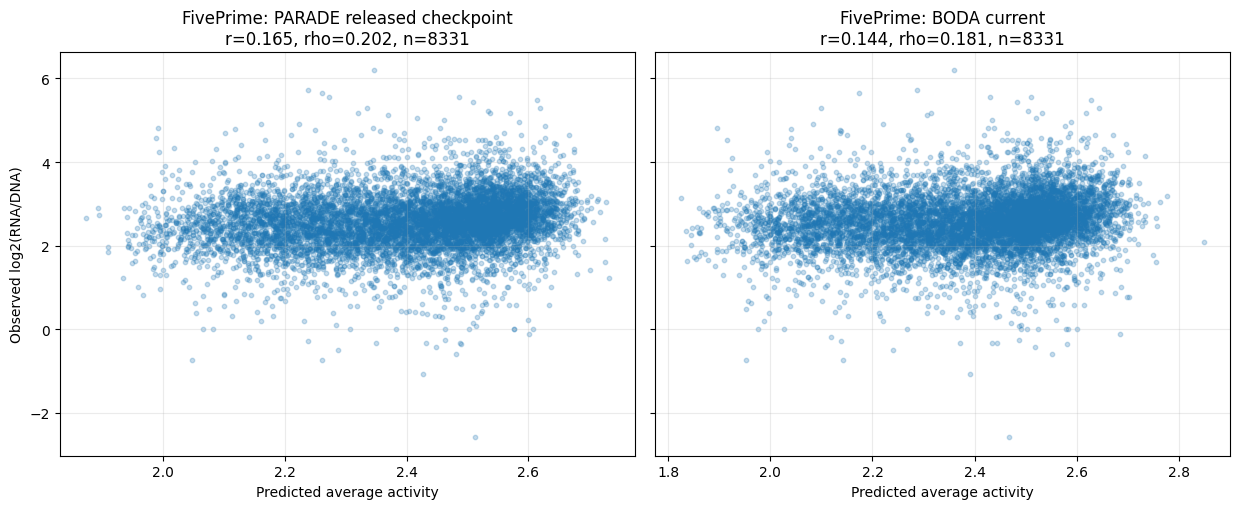

No exact-length ThreePrime candidates were scored. Current 3UTR checkpoints expect 240 nt inserts; see inhouse_utr_candidate_scoreability_summary.csv.


In [30]:
if not fiveprime_predictions.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharey=True)
    plot_specs = [
        ('parade_average_activity', 'PARADE released checkpoint'),
        ('boda_average_activity', 'BODA current'),
    ]
    for ax, (pred_col, title) in zip(axes, plot_specs):
        sub = fiveprime_predictions[[pred_col, 'log2_RNA_DNA']].dropna()
        ax.scatter(sub[pred_col], sub['log2_RNA_DNA'], s=10, alpha=0.25)
        r = pearson_np(sub[pred_col], sub['log2_RNA_DNA'])
        rho = spearman_np(sub[pred_col], sub['log2_RNA_DNA'])
        ax.set_title(f'FivePrime: {title}\nr={r:.3f}, rho={rho:.3f}, n={len(sub)}')
        ax.set_xlabel('Predicted average activity')
        ax.grid(alpha=0.25)
    axes[0].set_ylabel('Observed log2(RNA/DNA)')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'inhouse_fiveprime_predicted_activity_vs_log2_rna_dna.png', dpi=180, bbox_inches='tight')
    plt.show()

if threeprime_predictions.empty:
    print(
        'No exact-length ThreePrime candidates were scored. Current 3UTR checkpoints expect '
        f'{EXPECTED_INSERT_LENGTH["3UTR"]} nt inserts; see inhouse_utr_candidate_scoreability_summary.csv.'
    )


## Final Output Index

In [31]:
metadata = {
    'notebook': str(REPO_ROOT / 'tutorials' / 'lib1_tasks' / 'pretraining_CRE_public_data' / 'parade_released_checkpoint_eval_may2026.ipynb'),
    'created_for': 'Consolidated UTR HPO decision, PARADE released checkpoint agreement, and BODA current-model comparison',
    'parade_root': str(PARADE_ROOT),
    'parade_checkpoints': {k: str(v) for k, v in PARADE_CKPTS.items()},
    'boda_best_runs_csv': str(BEST_RUNS_CSV),
    'device': DEVICE,
    'cell_type_names': CELL_TYPE_NAMES,
    'sequence_length_policy': 'exact-length valid DNA only for in-house candidate scoring',
    'sequence_case_policy': 'Uppercase model inputs while preserving original sequence strings as scoring keys.',
    'author_notebook_policy': 'Author notebook benchmark values are used as a compact agreement check; main plots show one PARADE released-checkpoint series.',
    'threeprime_guardrail': 'Current 3UTR checkpoints expect 240 nt; in-house ThreePrime candidates are mostly 100 nt and are not padded/truncated by default.',
}
(OUT_DIR / 'parade_released_checkpoint_eval_metadata.json').write_text(json.dumps(metadata, indent=2, sort_keys=True) + '\n')

outputs = sorted(OUT_DIR.glob('*'))
print(f'Wrote/available outputs in {OUT_DIR}:')
for path in outputs:
    print('-', path.name)


Wrote/available outputs in /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/parade_released_checkpoint_eval_may2026:
- boda_current_3UTR_zlipechs_lib1_test_activity_predictions.csv
- boda_current_3UTR_zlipechs_lib2_overlap_activity_predictions.csv
- boda_current_5UTR_1mmy39ku_lib1_test_activity_predictions.csv
- boda_current_5UTR_1mmy39ku_lib2_overlap_activity_predictions.csv
- inhouse_fiveprime_boda_current_predictions.csv
- inhouse_fiveprime_parade_released_predictions.csv
- inhouse_fiveprime_parade_released_vs_boda_current_metrics.csv
- inhouse_fiveprime_parade_released_vs_boda_current_predictions.csv
- inhouse_fiveprime_predicted_activity_vs_log2_rna_dna.png
- inhouse_parade_released_vs_boda_current_metrics.csv
- inhouse_utr_candidate_scoreability_summary.csv
- parade_authors_notebook_reference_per_cell.csv
- parade_authors_notebook_reference_summary.csv
- parade_released_3UTR_lib1_test_activity_predictions.csv
- parade_released_3